# Übung 4 – ELISA: Analyse der Oberleitungs-Lkw auf der A5

Der **ELISA**-Feldversuch (*ELektrifizierter, Innovativer Schwerverkehr auf Autobahnen*) betreibt seit 2019
auf der **A5 zwischen Zeppelinheim und Darmstadt/Weiterstadt** einen eHighway-Abschnitt: Oberleitungen über
dem rechten Fahrstreifen, unter denen Hybrid-Lkw ihren **Pantograph** ausfahren und rein
elektrisch fahren.

Dieses Notebook wertet die **CAN-Bus-Rohdaten zweier Versuchsfahrzeuge** (`T1`, `T2`) aus dem September 2023
aus – rund **1,4 GB / 9,4 Mio. Messzeilen** bei 10 Hz Abtastrate – sowie die **amtlichen Unfalldaten der A5
für 2024**.

**Leitfragen**


**Aufbau:** Setup → Rohdaten → Datenqualität → Zeitreihe eines Fahrtags →
Pantograph & Energiebilanz → Hypothesentest 1 → Unfalldaten → Hypothesentest 2 → Fazit.

## 1. Setup und Datenübersicht

In [1]:
from pathlib import Path
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

# ── Farbsystem ────────────────────────────────────────────────────────────────
# Kategoriale Palette in FESTER Slot-Reihenfolge (nie umsortieren, nie zyklisch
# fortsetzen). Auf CVD-Sicherheit geprüft: schlechtestes benachbartes Delta-E = 24.2
# (Protanopie) -- deutlich über dem Zielwert 12.
SERIES = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
          "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
SURFACE = "#fcfcfb"
INK, INK2 = "#0b0b0b", "#52514e"

# Divergierend (Korrelationen): zwei gegensätzliche Pole + NEUTRALER grauer Mittelpunkt
CMAP_DIV = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#e8e8e6", "#e34948"])
# Ordinal (Unfallschwere, geordnete Klassen): ein Farbton, hell -> dunkel
RAMP_ORD = ["#86b6ef", "#3987e5", "#256abf", "#0d366b"]

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2,
    "axes.titlesize": 12, "axes.titlelocation": "left", "axes.titlepad": 10,
    "grid.color": "#d8d7d2", "grid.linewidth": 0.6, "grid.alpha": 0.7,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "lines.linewidth": 2.0, "lines.markersize": 8,
    "legend.frameon": False,
    "axes.prop_cycle": plt.cycler(color=SERIES),
})

BASE_DIR = Path.cwd()
CSV_FILES = sorted(BASE_DIR.glob("T*_2023_KW*.csv"))
EXCEL_PATH = BASE_DIR / "Unfalldaten A5 2024.xlsx"

print(f"Arbeitsverzeichnis   : {BASE_DIR}")
print(f"CAN-CSV-Dateien      : {len(CSV_FILES)}")
print(f"Unfall-Excel gefunden: {EXCEL_PATH.exists()}")

Arbeitsverzeichnis   : c:\Users\kevin\OneDrive - stud.tu-darmstadt.de\Uni_Master\Master_BauIng_4. Semester\Small and Big Data in der Verkehrstechnik\Übung 4 - ELISA Daten
CAN-CSV-Dateien      : 9
Unfall-Excel gefunden: True


In [2]:
# Dateiname -> Metadaten (Fahrzeug, Kalenderwoche, abgedeckter Zeitraum)
FNAME_RE = re.compile(r"^(T\d)_(\d{4})_KW(\d+)_(\d{4}-\d{2}-\d{2})_bis_(\d{4}-\d{2}-\d{2})\.csv$")

inventory = []
for p in CSV_FILES:
    m = FNAME_RE.match(p.name)
    inventory.append({
        "Datei": p.name, "Lkw": m.group(1), "KW": int(m.group(3)),
        "von": m.group(4), "bis": m.group(5),
        "MB": round(p.stat().st_size / 1e6, 1),
    })
inventory_df = pd.DataFrame(inventory)

total_mb = inventory_df["MB"].sum()
print(f"Gesamtvolumen: {total_mb:,.0f} MB  ({total_mb/1024:.2f} GB)")
print(f"Fahrzeuge: {sorted(inventory_df['Lkw'].unique())}   Kalenderwochen: {sorted(inventory_df['KW'].unique())}")
inventory_df

Gesamtvolumen: 1,402 MB  (1.37 GB)
Fahrzeuge: ['T1', 'T2']   Kalenderwochen: [np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39)]


,Datei,Lkw,KW,von,bis,MB
0,T1_2023_KW35_2023-09-01_bis_2023-09-01.csv,T1,35,2023-09-01,2023-09-01,45.6
1,T1_2023_KW37_2023-09-11_bis_2023-09-16.csv,T1,37,2023-09-11,2023-09-16,126.5
2,T1_2023_KW38_2023-09-18_bis_2023-09-22.csv,T1,38,2023-09-18,2023-09-22,168.1
3,T1_2023_KW39_2023-09-25_bis_2023-09-29.csv,T1,39,2023-09-25,2023-09-29,206.8
4,T2_2023_KW35_2023-09-01_bis_2023-09-01.csv,T2,35,2023-09-01,2023-09-01,45.2
5,T2_2023_KW36_2023-09-04_bis_2023-09-08.csv,T2,36,2023-09-04,2023-09-08,202.6
6,T2_2023_KW37_2023-09-11_bis_2023-09-15.csv,T2,37,2023-09-11,2023-09-15,200.4
7,T2_2023_KW38_2023-09-18_bis_2023-09-22.csv,T2,38,2023-09-18,2023-09-22,213.3
8,T2_2023_KW39_2023-09-25_bis_2023-09-30.csv,T2,39,2023-09-25,2023-09-30,193.4


## 2. Rohdaten laden und inspizieren

Die CSVs sind im **deutschen Format** abgelegt: `;` als Spaltentrenner, `,` als Dezimalzeichen.
Ohne `sep=";"` und `decimal=","` liest pandas jede Zeile als einen einzigen String ein.

In [3]:
sample_path = BASE_DIR / "T1_2023_KW35_2023-09-01_bis_2023-09-01.csv"

t0 = time.time()
raw = pd.read_csv(sample_path, sep=";", decimal=",", parse_dates=["TIME"])
print(f"{sample_path.name}: {raw.shape[0]:,} Zeilen x {raw.shape[1]} Spalten "
      f"in {time.time()-t0:.1f} s geladen\n")

raw.head()

T1_2023_KW35_2023-09-01_bis_2023-09-01.csv: 318,990 Zeilen x 21 Spalten in 1.7 s geladen



,EM_Speed (rpm),EM2_Speed (rpm),TIME,HighResolTotalVehicleDistance,PowerManagerEngineState,EngineSpeed (rpm),PantographActualStatus,FuelRate (L/h),EM_Current (A),EM2_Current (A),EM_Voltage (V),EM2_Voltage (V),WheelBasedVehicleSpeed (km/h),BatterySOC,TrailerWeight (kg),CargoWeight (kg),AxleWeight (kg),BatteryVoltage,BatteryCurrent,MeasuredOclCurrent,MeasuredOclVoltage
0,0.0,NaN,2023-09-01 02:53:48.986728+00:00,NaN,2.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,660.75,11.80,0.0,0.0
1,0.0,NaN,2023-09-01 02:53:49.086776+00:00,NaN,2.0,0.0,1.0,0.0,0.0,NaN,660.9,NaN,0.0,52.688,0.0,130048.0,32640.0,660.70,11.70,0.0,0.0
2,0.0,NaN,2023-09-01 02:53:49.186775+00:00,NaN,2.0,0.0,1.0,0.0,0.0,NaN,660.9,NaN,0.0,52.688,0.0,130048.0,32640.0,660.70,11.70,0.0,0.0
3,0.0,NaN,2023-09-01 02:53:49.286773+00:00,NaN,2.0,0.0,1.0,0.0,0.0,NaN,661.0,NaN,0.0,52.686,0.0,130048.0,32640.0,660.70,11.70,0.0,0.0
4,0.0,NaN,2023-09-01 02:53:49.386775+00:00,NaN,2.0,0.0,1.0,0.0,0.0,NaN,661.0,NaN,0.0,52.686,0.0,130048.0,32640.0,660.70,11.75,0.0,0.0


In [4]:
raw.info()

# Abtastrate und Vollständigkeit
dt = raw["TIME"].diff().dt.total_seconds()
print(f"\nMedianer Abtastabstand : {dt.median():.3f} s  ->  {1/dt.median():.0f} Hz")
print(f"Zeitraum               : {raw.TIME.min()}  bis  {raw.TIME.max()}")
print(f"Zeitstempel monoton    : {raw.TIME.is_monotonic_increasing},  Duplikate: {raw.TIME.duplicated().sum()}")
print(f"Lücken > 5 s           : {(dt > 5).sum()}  (Summe {dt[dt>5].sum()/3600:.1f} h)")

print("\nAnteil belegter Werte je Spalte:")
print(raw.notna().mean().sort_values().round(3).to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318990 entries, 0 to 318989
Data columns (total 21 columns):
 #   Column                         Non-Null Count   Dtype              
---  ------                         --------------   -----              
 0   EM_Speed (rpm)                 318990 non-null  float64            
 1   EM2_Speed (rpm)                0 non-null       float64            
 2   TIME                           318990 non-null  datetime64[ns, UTC]
 3   HighResolTotalVehicleDistance  318944 non-null  float64            
 4   PowerManagerEngineState        318989 non-null  float64            
 5   EngineSpeed (rpm)              318990 non-null  float64            
 6   PantographActualStatus         318990 non-null  float64            
 7   FuelRate (L/h)                 318986 non-null  float64            
 8   EM_Current (A)                 318987 non-null  float64            
 9   EM2_Current (A)                0 non-null       float64            
 10  EM_Volta

### Bedeutung der Spalten

Die Signale stammen aus dem **CAN-Bus** des Fahrzeugs (Norm **SAE J1939**), zusätzlich die vom
Stromabnehmer gemessenen Oberleitungsgrößen (`Ocl` = *Overhead Contact Line*).

| Spalte | Bedeutung | Einheit |
|---|---|---|
| `TIME` | Zeitstempel des Messpunkts (UTC), 10 Hz | – |
| `WheelBasedVehicleSpeed (km/h)` | Fahrzeuggeschwindigkeit aus der Raddrehzahl | km/h |
| `HighResolTotalVehicleDistance` | Gesamt-Kilometerstand (Odometer), Auflösung 5 m | km |
| `EngineSpeed (rpm)` | Drehzahl des **Dieselmotors** (0 = Motor aus) | min⁻¹ |
| `FuelRate (L/h)` | Momentaner **Kraftstoffverbrauch** | L/h |
| `PowerManagerEngineState` | Betriebszustand des Antriebsstrang-Managements | Code |
| `PantographActualStatus` | **Zustand des Stromabnehmers** (siehe unten) | Code |
| `MeasuredOclVoltage` / `MeasuredOclCurrent` | An der **Oberleitung** gemessene Spannung / Strom | V / A |
| `EM_*` / `EM2_*` (`Speed`, `Current`, `Voltage`) | **Elektromotor 1 / 2**: Drehzahl, Strom, Spannung | min⁻¹ / A / V |
| `BatterySOC` | **Ladezustand** der Traktionsbatterie | % |
| `BatteryVoltage` / `BatteryCurrent` | Batteriespannung / -strom (Vorzeichen: **+ = Entladen**, − = Laden) | V / A |
| `TrailerWeight (kg)` / `AxleWeight (kg)` | Anhänger- bzw. Achslast | kg |
| `CargoWeight (kg)` | Ladungsgewicht – **im Datensatz durchgängig ungültig** (s. Kapitel 3) | kg |

**Pantograph-Zustände** (empirisch über die gemessene Oberleitungsspannung verifiziert, s. Kapitel 3):

| Code | Bedeutung | mittlere OL-Spannung |
|---|---|---|
| 0 | undefiniert / Initialisierung | 0 V |
| 1 | eingefahren (Dieselfahrt) | ≈ 0 V |
| 2 | fährt aus | ≈ 2 V |
| 3 | Kontakt wird hergestellt | ≈ 124 V |
| 4 | **Kontakt – Fahrt unter Oberleitung** | ≈ 675 V |
| 6 | fährt ein / Kontaktverlust | ≈ 35 V |

**Zwei unterschiedliche Fahrzeuge:** `T1` besitzt **einen** Elektromotor (`EM2_*` durchgängig leer),
`T2` besitzt **zwei** (`EM_*` und `EM2_*` belegt).

## 3. Datenqualität: die J1939-Sentinel-Werte

Der wichtigste Fallstrick dieses Datensatzes: **fehlende Messwerte stehen nicht als `NaN` in der Datei.**
Der CAN-Standard SAE J1939 kodiert „Signal nicht verfügbar" als **alle Bits gesetzt** (`0xFFFF`) und
„Messfehler" als `0xFExx`. Nach Anwendung des Skalierungsfaktors werden daraus scheinbar harmlose Zahlen –
die pandas bereitwillig mitmittelt.

Man erkennt sie daran, dass der **Maximalwert isoliert weit über dem zweitgrößten Wert liegt**:

In [5]:
check_cols = ["EngineSpeed (rpm)", "FuelRate (L/h)", "WheelBasedVehicleSpeed (km/h)",
              "BatterySOC", "MeasuredOclVoltage", "MeasuredOclCurrent",
              "EM_Current (A)", "BatteryVoltage", "AxleWeight (kg)", "CargoWeight (kg)"]

rows = []
for c in check_cols:
    uniq = np.sort(raw[c].dropna().unique())[::-1]
    rows.append({"Spalte": c,
                 "größter Wert": uniq[0],
                 "zweitgrößter": uniq[1] if len(uniq) > 1 else np.nan,
                 "drittgrößter": uniq[2] if len(uniq) > 2 else np.nan})

gap_df = pd.DataFrame(rows)
gap_df["Sprung (Faktor)"] = (gap_df["größter Wert"] / gap_df["zweitgrößter"]).round(1)
gap_df

,Spalte,größter Wert,zweitgrößter,drittgrößter,Sprung (Faktor)
0,EngineSpeed (rpm),8191.8750,2335.5000,2335.250,3.5
1,FuelRate (L/h),3276.7500,77.3500,77.150,42.4
2,WheelBasedVehicleSpeed (km/h),255.9961,90.5859,90.582,2.8
3,BatterySOC,68.3680,68.3660,68.364,1.0
4,MeasuredOclVoltage,734.5000,733.0000,732.500,1.0
5,MeasuredOclCurrent,234.0000,233.0000,231.900,1.0
6,EM_Current (A),1676.7500,250.8000,245.100,6.7
7,BatteryVoltage,711.0500,711.0000,710.950,1.0
8,AxleWeight (kg),32640.0000,13757.5000,13740.500,2.4
9,CargoWeight (kg),130560.0000,130048.0000,NaN,1.0


Der Sprung ist eindeutig: `FuelRate` springt von 77,4 L/h auf **3276,75 L/h**, die Geschwindigkeit von
92,4 km/h auf **255,996 km/h**. Rechnet man die Skalierungsfaktoren der jeweiligen J1939-Parameter zurück,
ergibt sich exakt der 16-Bit-Maximalwert `65535`:

| Signal | Auflösung / Offset | 65535 × Auflösung | beobachteter Sentinel |
|---|---|---|---|
| `EngineSpeed` | 0,125 min⁻¹ | 8191,875 | **8191,875** |
| `FuelRate`, `BatteryVoltage` | 0,05 | 3276,75 | **3276,75** |
| `WheelBasedVehicleSpeed` | 1/256 km/h | 255,996 | **255,996** |
| `BatterySOC` | 0,002 % | 131,07 | **131,07** |
| `EM_Current`, `BatteryCurrent`, `MeasuredOclCurrent` | 0,05 A, Offset −1600 | 1676,75 | **1676,75** |
| `CargoWeight`, `TrailerWeight` | 2 kg | 131070 | **131070** (u. 130560 / 130048) |
| `AxleWeight` | 0,5 kg | 32767,5 | **32767,5** (u. 32640) |
| `MeasuredOclVoltage` | 8 V (1 Byte) | 255 × 8 = 2040 | **2040** |

> ⚠️ Würde man diese Werte nicht maskieren, ergäbe sich für `T2` (KW 35) ein mittlerer Strom des zweiten
> E-Motors von **428 A** statt der realen **2,05 A** – der Mittelwert wäre um **Faktor 208** verfälscht.
> Bei `EM_Current` kippt sogar das Vorzeichen (roh +316 A, bereinigt −6,2 A).

In [6]:
# ── Bereinigungs-Regeln ───────────────────────────────────────────────────────
# 1) J1939-Sentinels: alles >= Sentinel - eps ist "nicht verfügbar"/"Fehler"
SENTINELS = {
    "EM_Speed (rpm)": 8031.875, "EM2_Speed (rpm)": 8031.875,
    "EngineSpeed (rpm)": 8191.875, "FuelRate (L/h)": 3276.75,
    "EM_Current (A)": 1676.75, "EM2_Current (A)": 1676.75,
    "EM_Voltage (V)": 3276.75, "EM2_Voltage (V)": 3276.75,
    "WheelBasedVehicleSpeed (km/h)": 255.9961, "BatterySOC": 131.07,
    "TrailerWeight (kg)": 130048.0, "CargoWeight (kg)": 130048.0,
    "AxleWeight (kg)": 32640.0, "BatteryVoltage": 3276.75,
    "BatteryCurrent": 1676.75, "MeasuredOclCurrent": 1676.75,
    "MeasuredOclVoltage": 2040.0,
}
# 2) Physikalische Plausibilitätsgrenzen (fangen Rest-Artefakte ab)
PHYS_RANGE = {
    "EM_Voltage (V)": (0, 900), "EM2_Voltage (V)": (0, 900), "BatteryVoltage": (0, 900),
    "MeasuredOclVoltage": (0, 900),      # ELISA: 670 V DC nominal
    "MeasuredOclCurrent": (-400, 400), "BatteryCurrent": (-500, 500),
    "EM_Current (A)": (-500, 500), "EM2_Current (A)": (-500, 500),
}

PANTO_LABELS = {0: "undefiniert", 1: "eingefahren", 2: "fährt aus",
                3: "Kontakt herstellen", 4: "Kontakt (unter OL)", 6: "fährt ein"}
CONTACT = 4          # Pantograph-Code für "Fahrt unter Oberleitung"
DT_CAP = 0.2         # s -- Obergrenze für die Zeitschritt-Integration
DIST_CAP = 0.5       # km -- Obergrenze für einen plausiblen Odometer-Zuwachs


def clean(df):
    """Maskiert Sentinels + unplausible Werte. Gibt (df, Report) zurück.

    Verarbeitet nur die tatsächlich vorhandenen Spalten -- der Vollimport und der
    spätere `usecols`-Import (Kapitel 4) haben unterschiedliche Spaltensätze.
    """
    report = []
    for c, s in SENTINELS.items():
        if c not in df.columns:
            continue
        m = df[c] >= s - 0.01
        if m.any():
            report.append({"Spalte": c, "Sentinel": int(m.sum()), "unplausibel": 0})
        df.loc[m, c] = np.nan
    for c, (lo, hi) in PHYS_RANGE.items():
        if c not in df.columns:
            continue
        m = (df[c] < lo) | (df[c] > hi)
        if m.any():
            hit = next((r for r in report if r["Spalte"] == c), None)
            if hit: hit["unplausibel"] = int(m.sum())
            else:   report.append({"Spalte": c, "Sentinel": 0, "unplausibel": int(m.sum())})
        df.loc[m, c] = np.nan
    return df, pd.DataFrame(report)


sample_clean, sample_report = clean(raw.copy())
n = len(raw)
sample_report["Anteil %"] = ((sample_report.Sentinel + sample_report.unplausibel) / n * 100).round(2)
print(f"Bereinigung von {sample_path.name} ({n:,} Zeilen):\n")
print(sample_report.sort_values("Anteil %", ascending=False).to_string(index=False))

Bereinigung von T1_2023_KW35_2023-09-01_bis_2023-09-01.csv (318,990 Zeilen):

                       Spalte  Sentinel  unplausibel  Anteil %
             CargoWeight (kg)    318983            0    100.00
              AxleWeight (kg)     61383            0     19.24
WheelBasedVehicleSpeed (km/h)      1327            0      0.42
               EM_Current (A)      1140            0      0.36
           TrailerWeight (kg)       726            0      0.23
               FuelRate (L/h)         5            0      0.00
            EngineSpeed (rpm)         2            0      0.00


In [7]:
# Effekt der Bereinigung auf die Statistik.
# T1 ist kaum betroffen (wenige Sentinels) -- T2 dagegen massiv, deshalb beide zeigen.
t2_path = BASE_DIR / "T2_2023_KW35_2023-09-01_bis_2023-09-01.csv"
t2_raw = pd.read_csv(t2_path, sep=";", decimal=",",
                     usecols=["EM_Current (A)", "EM2_Current (A)", "BatterySOC"])
t2_clean, _ = clean(t2_raw.copy())

cmp_t1 = ["FuelRate (L/h)", "WheelBasedVehicleSpeed (km/h)", "EngineSpeed (rpm)"]
cmp_t2 = ["EM_Current (A)", "EM2_Current (A)", "BatterySOC"]

effect = pd.concat([
    pd.DataFrame({"Datei": "T1 KW35", "Mittelwert roh": raw[cmp_t1].mean(),
                  "Mittelwert bereinigt": sample_clean[cmp_t1].mean(),
                  "Maximum roh": raw[cmp_t1].max()}),
    pd.DataFrame({"Datei": "T2 KW35", "Mittelwert roh": t2_raw[cmp_t2].mean(),
                  "Mittelwert bereinigt": t2_clean[cmp_t2].mean(),
                  "Maximum roh": t2_raw[cmp_t2].max()}),
])
effect["Faktor roh/bereinigt"] = (effect["Mittelwert roh"] / effect["Mittelwert bereinigt"])
effect.round(2)

,Datei,Mittelwert roh,Mittelwert bereinigt,Maximum roh,Faktor roh/bereinigt
FuelRate (L/h),T1 KW35,14.53,14.48,3276.75,1.00
WheelBasedVehicleSpeed (km/h),T1 KW35,51.11,50.26,256.00,1.02
EngineSpeed (rpm),T1 KW35,824.66,824.62,8191.88,1.00
EM_Current (A),T2 KW35,315.71,-6.20,1676.75,-50.94
EM2_Current (A),T2 KW35,428.06,2.05,1676.75,208.30
BatterySOC,T2 KW35,70.42,70.42,131.07,1.00


In [8]:
# CargoWeight: enthält AUSSCHLIESSLICH Sentinel-/Fehlercodes -> Spalte ist wertlos
print("CargoWeight – Werteverteilung (roh):")
print(raw["CargoWeight (kg)"].value_counts(dropna=False).to_string())
print(f"\nGültige Werte nach Bereinigung: {sample_clean['CargoWeight (kg)'].notna().sum()}")
print("=> Spalte wird in der weiteren Analyse verworfen.")

CargoWeight – Werteverteilung (roh):
CargoWeight (kg)
130560.0    314564
130048.0      4419
NaN              7

Gültige Werte nach Bereinigung: 0
=> Spalte wird in der weiteren Analyse verworfen.


### Verifikation der Pantograph-Codes

Die Bedeutung der `PantographActualStatus`-Codes ist nicht dokumentiert. Sie lässt sich aber
**aus den Daten erschließen**, indem man die gemessene Oberleitungsspannung je Code betrachtet:

In [9]:
panto_check = (
    sample_clean
    .groupby("PantographActualStatus")
    .agg(Messpunkte=("TIME", "size"),
         Zeitanteil_pct=("TIME", lambda s: len(s) / len(sample_clean) * 100),
         OL_Spannung_V=("MeasuredOclVoltage", "mean"),
         Anteil_V_ueber_100=("MeasuredOclVoltage", lambda s: (s > 100).mean() * 100),
         OL_Strom_A=("MeasuredOclCurrent", "mean"),
         Verbrauch_L_h=("FuelRate (L/h)", "mean"),
         Geschw_kmh=("WheelBasedVehicleSpeed (km/h)", "mean"))
    .round(2)
)
panto_check.index = [f"{int(i)} – {PANTO_LABELS.get(int(i), '?')}" for i in panto_check.index]
panto_check

,Messpunkte,Zeitanteil_pct,OL_Spannung_V,Anteil_V_ueber_100,OL_Strom_A,Verbrauch_L_h,Geschw_kmh
0 – undefiniert,1201,0.38,0.00,0.00,0.00,0.23,NaN
1 – eingefahren,310384,97.30,0.03,0.00,0.00,14.79,49.41
2 – fährt aus,476,0.15,1.93,0.00,0.00,24.52,87.24
3 – Kontakt herstellen,100,0.03,123.98,18.00,0.04,0.74,87.37
4 – Kontakt (unter OL),6633,2.08,675.46,99.94,137.30,2.17,86.40
6 – fährt ein,196,0.06,35.08,6.12,4.23,2.55,66.49


Damit ist Code **4 = elektrischer Kontakt** zweifelsfrei identifiziert: nur dort liegen ~675 V an,
fließen ~137 A – und der Dieselverbrauch bricht von **14,8 L/h auf 2,2 L/h** ein. Die Codes 2, 3 und 6
sind kurze Übergangszustände (An-/Abdrahten).

## 4. Effizientes Laden aller 1,4 GB

Die neun Dateien zusammen als `float64`-DataFrame zu halten, kostet **≈ 1,6 GB RAM**. Für ein
„Small & Big Data"-Setting nutzen wir drei Standardtechniken:

1. **Streaming statt Vollmaterialisierung** – jede Datei wird einzeln geladen, bereinigt, ausgewertet und
   wieder verworfen. Die *Aggregate* (Kennzahlen, Fahrtblöcke) sind winzig.
2. **Downcasting** `float64 → float32` – halbiert den Speicher, die Sensorauflösung (4–5 signifikante
   Stellen) geht dabei nicht verloren.
3. **Dezimierung** – für Überblicksgrafiken und Korrelationen genügt **1 Hz**; jeder 10. Messpunkt wird
   behalten. Energie- und Verbrauchsintegrale werden dagegen auf der **vollen 10-Hz-Auflösung** gerechnet,
   damit keine Leistungsspitze verlorengeht.

Integriert wird mit dem **tatsächlichen** Zeitschritt `dt` (auf 0,2 s gedeckelt), damit die
Aufzeichnungslücken (Nachtpausen) die Integrale nicht aufblähen.

In [10]:
KEEP = ["TIME", "WheelBasedVehicleSpeed (km/h)", "HighResolTotalVehicleDistance",
        "EngineSpeed (rpm)", "FuelRate (L/h)", "PantographActualStatus",
        "MeasuredOclVoltage", "MeasuredOclCurrent", "BatterySOC",
        "BatteryVoltage", "BatteryCurrent", "EM_Current (A)", "EM_Voltage (V)",
        "EM2_Current (A)", "EM2_Voltage (V)", "EM_Speed (rpm)", "EM2_Speed (rpm)",
        "TrailerWeight (kg)", "AxleWeight (kg)", "PowerManagerEngineState"]


def derive(df):
    """Physikalisch abgeleitete Größen: Zeitschritt, Leistungen, Fahrzustände."""
    df["dt_s"] = df["TIME"].diff().dt.total_seconds().clip(upper=DT_CAP).fillna(0.1)

    # Leistung [kW] = U * I / 1000.  P_ocl < 0  =>  Rückspeisung (Rekuperation)
    df["P_ocl_kW"] = (df["MeasuredOclVoltage"] * df["MeasuredOclCurrent"] / 1000).fillna(0.0)
    df["P_bat_kW"] = df["BatteryVoltage"] * df["BatteryCurrent"] / 1000
    em = df["EM_Voltage (V)"] * df["EM_Current (A)"]
    if df["EM2_Current (A)"].notna().any():
        em = em.add(df["EM2_Voltage (V)"] * df["EM2_Current (A)"], fill_value=0)
    df["P_em_kW"] = em / 1000

    df["catenary"] = df["PantographActualStatus"] == CONTACT
    df["moving"] = df["WheelBasedVehicleSpeed (km/h)"] > 1.0
    df["engine_off"] = df["EngineSpeed (rpm)"] < 50

    # Odometer-Zuwachs, gegen Sprünge über Aufzeichnungslücken abgesichert
    d = df["HighResolTotalVehicleDistance"].diff()
    df["d_km"] = d.where((d > 0) & (d < DIST_CAP), 0.0)
    return df


def summarize(df, meta):
    """Kennzahlen einer Datei -- auf voller 10-Hz-Auflösung integriert."""
    dt, cat = df["dt_s"], df["catenary"]
    p = df["P_ocl_kW"]
    km = df["d_km"].sum()
    fuel = (df["FuelRate (L/h)"] * dt).sum() / 3600            # Liter
    return {
        **meta,
        "Zeilen": len(df),
        "Aufz. h": dt.sum() / 3600,
        "Fahrt h": (dt * df["moving"]).sum() / 3600,
        "OL h": (dt * cat).sum() / 3600,
        "km": km,
        "km (aus v·dt)": (df["WheelBasedVehicleSpeed (km/h)"] * dt).sum() / 3600,
        "km unter OL": df.loc[cat, "d_km"].sum(),
        "OL-Anteil %": df.loc[cat, "d_km"].sum() / km * 100 if km else np.nan,
        "Diesel L": fuel,
        "L/100km": fuel / km * 100 if km else np.nan,
        "E_OL kWh (Bezug)": (p.clip(lower=0) * dt).sum() / 3600,
        "E_OL kWh (Rekup.)": -(p.clip(upper=0) * dt).sum() / 3600,
        "P_OL Ø kW": df.loc[cat, "P_ocl_kW"].mean(),
        "P_OL max kW": df.loc[cat, "P_ocl_kW"].max(),
        "U_OL Ø V": df.loc[cat, "MeasuredOclVoltage"].mean(),
    }


def extract_blocks(df, truck, min_s=30, v_min=70):
    """Unabhängige Analyse-Einheiten für den Hypothesentest.

    Ein 'Block' ist eine zusammenhängende Autobahn-Fahrtphase (v > 70 km/h) in
    genau einem Betriebsmodus. Blockgrenzen: Moduswechsel ODER Datenlücke > 2 s.
    Nur Blöcke >= 30 s. So wird die starke Autokorrelation der 10-Hz-Rohdaten
    vermieden (sonst Pseudo-Replikation, s. Kapitel 7).
    """
    d = df[df["WheelBasedVehicleSpeed (km/h)"] > v_min].copy()
    d = d[d["PantographActualStatus"].isin([1, CONTACT])]
    if d.empty:
        return pd.DataFrame()
    d["Modus"] = np.where(d["PantographActualStatus"] == CONTACT, "Oberleitung", "Diesel")
    gap = d["TIME"].diff().dt.total_seconds().fillna(999) > 2
    d["blk"] = ((d["Modus"] != d["Modus"].shift()) | gap).cumsum()

    g = d.groupby("blk").agg(
        Modus=("Modus", "first"),
        n=("TIME", "size"),
        Dauer_s=("dt_s", "sum"),
        Verbrauch_L_h=("FuelRate (L/h)", "mean"),
        Geschw_kmh=("WheelBasedVehicleSpeed (km/h)", "mean"),
        Motor_aus_pct=("engine_off", lambda s: s.mean() * 100),
        Start=("TIME", "first"),
    )
    g = g[g["Dauer_s"] >= min_s].copy()
    g["Lkw"] = truck
    return g

In [11]:
# ── Ein Durchlauf über alle Dateien: Streaming + Downcast + Dezimierung ───────
summaries, blocks, hz1 = [], [], []
mem_raw_total = 0.0

t_start = time.time()
for p in CSV_FILES:
    m = FNAME_RE.match(p.name)
    meta = {"Lkw": m.group(1), "KW": int(m.group(3))}
    t = time.time()

    df = pd.read_csv(p, sep=";", decimal=",", parse_dates=["TIME"], usecols=KEEP)
    mem_raw = df.memory_usage(deep=True).sum() / 1e6
    mem_raw_total += mem_raw

    df, _ = clean(df)
    df = df.drop(columns=[c for c in ["CargoWeight (kg)"] if c in df.columns])
    df = df.dropna(subset=["TIME"]).sort_values("TIME").reset_index(drop=True)
    for c in df.select_dtypes("float64").columns:      # Downcast
        df[c] = df[c].astype("float32")
    df = derive(df)

    summaries.append(summarize(df, meta))
    b = extract_blocks(df, meta["Lkw"])
    if not b.empty:
        blocks.append(b)

    dec = df.iloc[::10].copy()                          # Dezimierung 10 Hz -> 1 Hz
    dec["Lkw"] = meta["Lkw"]
    hz1.append(dec)

    print(f"  {p.name:48s} {len(df):>9,} Zeilen  {mem_raw:6.0f} MB roh  {time.time()-t:5.1f} s", flush=True)
    del df

overview = pd.DataFrame(summaries)
blocks_df = pd.concat(blocks, ignore_index=True)
hz1_df = pd.concat(hz1, ignore_index=True)
del hz1, blocks

mem_hz1 = hz1_df.memory_usage(deep=True).sum() / 1e6
print(f"\nGesamtdauer: {time.time()-t_start:.0f} s")
print(f"Rohdaten (float64, 10 Hz, kumuliert) : {mem_raw_total:8,.0f} MB")
print(f"Arbeitsdatensatz (float32, 1 Hz)     : {mem_hz1:8,.0f} MB   "
      f"(Faktor {mem_raw_total/mem_hz1:.0f} kleiner)")
print(f"Fahrtblöcke für den Hypothesentest   : {len(blocks_df):,} Zeilen")

  T1_2023_KW35_2023-09-01_bis_2023-09-01.csv         318,990 Zeilen      51 MB roh    2.0 s
  T1_2023_KW37_2023-09-11_bis_2023-09-16.csv         917,708 Zeilen     147 MB roh    5.2 s
  T1_2023_KW38_2023-09-18_bis_2023-09-22.csv       1,192,502 Zeilen     191 MB roh    7.1 s
  T1_2023_KW39_2023-09-25_bis_2023-09-29.csv       1,447,119 Zeilen     232 MB roh   12.4 s
  T2_2023_KW35_2023-09-01_bis_2023-09-01.csv         293,007 Zeilen      47 MB roh    2.5 s
  T2_2023_KW36_2023-09-04_bis_2023-09-08.csv       1,309,344 Zeilen     209 MB roh   10.0 s
  T2_2023_KW37_2023-09-11_bis_2023-09-15.csv       1,297,197 Zeilen     208 MB roh   11.1 s
  T2_2023_KW38_2023-09-18_bis_2023-09-22.csv       1,381,905 Zeilen     221 MB roh   12.0 s
  T2_2023_KW39_2023-09-25_bis_2023-09-30.csv       1,256,308 Zeilen     201 MB roh   10.0 s

Gesamtdauer: 73 s
Rohdaten (float64, 10 Hz, kumuliert) :    1,506 MB
Arbeitsdatensatz (float32, 1 Hz)     :      153 MB   (Faktor 10 kleiner)
Fahrtblöcke für den Hypothese

In [12]:
show = overview.drop(columns=["km (aus v·dt)"]).copy()
show["Zeilen"] = show["Zeilen"].map("{:,}".format)
for c in show.select_dtypes("number").columns:
    if c != "KW":
        show[c] = show[c].round(2)
show

,Lkw,KW,Zeilen,Aufz. h,Fahrt h,OL h,km,km unter OL,OL-Anteil %,Diesel L,L/100km,E_OL kWh (Bezug),E_OL kWh (Rekup.),P_OL Ø kW,P_OL max kW,U_OL Ø V
0,T1,35,"318,990",8.86,7.34,0.18,443.500000,15.970000,3.600000,128.30,28.93,17.15,0.20,91.930000,150.929993,675.460022
1,T1,37,"917,708",25.49,18.69,0.80,1183.250000,66.379997,5.610000,316.97,26.79,51.15,0.64,62.869999,152.460007,686.909973
2,T1,38,"1,192,502",33.13,26.22,1.09,1613.689941,90.779999,5.630000,437.30,27.10,87.60,0.82,79.660004,151.259995,681.280029
3,T1,39,"1,447,119",40.20,33.23,1.57,2163.879883,131.440002,6.070000,546.21,25.24,126.67,1.67,79.739998,152.710007,680.270020
4,T2,35,"293,007",8.14,5.18,0.03,279.739990,2.390000,0.850000,63.02,22.53,5.78,0.00,187.559998,207.309998,659.280029
5,T2,36,"1,309,344",36.37,23.77,1.41,1467.119995,112.879997,7.690000,264.49,18.03,252.51,0.00,179.039993,211.389999,664.580017
6,T2,37,"1,297,197",36.04,22.09,1.04,1388.869995,81.699997,5.880000,246.62,17.76,194.17,0.00,186.639999,211.110001,664.200012
7,T2,38,"1,381,905",38.39,22.20,1.75,1366.739990,137.869995,10.090000,238.56,17.45,316.83,0.00,181.070007,215.899994,664.659973
8,T2,39,"1,256,308",34.90,20.00,3.05,1192.969971,238.089996,19.959999,144.84,12.14,543.18,0.00,178.089996,210.750000,655.419983


Die Tabelle zeigt bereits den Kern des Versuchs. Zwei Beobachtungen stechen heraus:

* **`T2` in KW 39** fuhr **20 %** seiner Kilometer unter Oberleitung und verbrauchte nur **12,1 L/100 km** –
  gegenüber 17,8 L/100 km in KW 37 mit 5,9 % Oberleitungsanteil.
* **`T1`** verbraucht mit **25–29 L/100 km** durchweg deutlich mehr als `T2` (12–23 L/100 km).

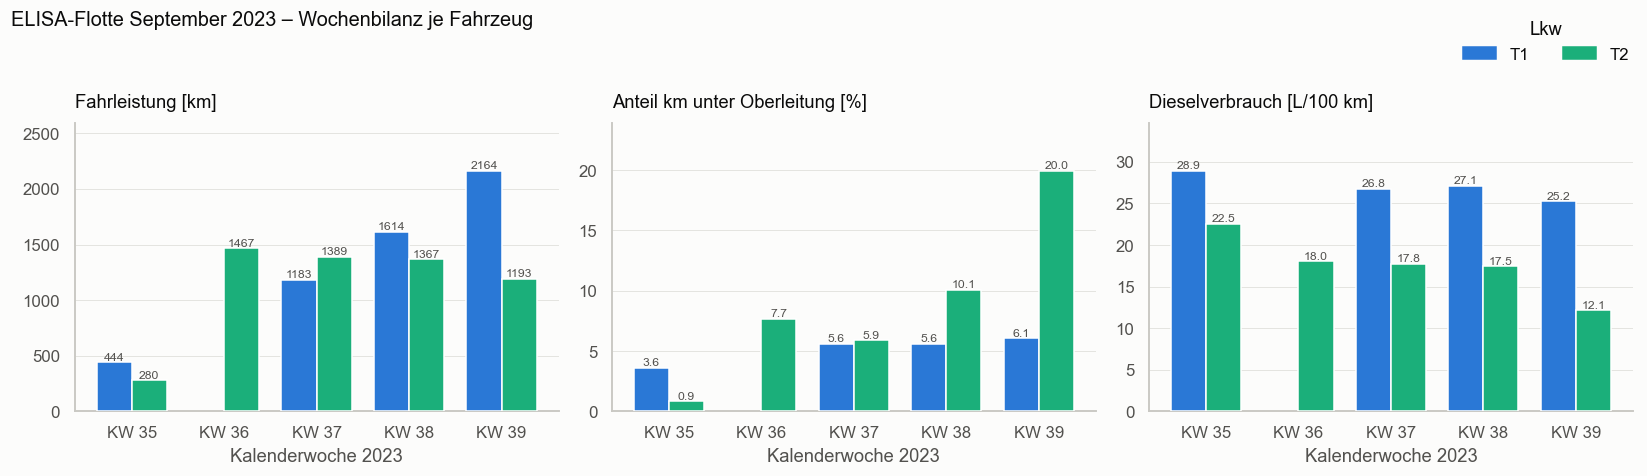

In [13]:
# ── Flottenüberblick: km, Oberleitungsanteil, Verbrauch ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
metrics = [("km", "Fahrleistung [km]", "{:.0f}"),
           ("OL-Anteil %", "Anteil km unter Oberleitung [%]", "{:.1f}"),
           ("L/100km", "Dieselverbrauch [L/100 km]", "{:.1f}")]
trucks = ["T1", "T2"]
kws = sorted(overview["KW"].unique())
x = np.arange(len(kws))
w = 0.38

for ax, (col, title, fmt) in zip(axes, metrics):
    for i, tr in enumerate(trucks):
        sub = overview[overview["Lkw"] == tr].set_index("KW").reindex(kws)
        pos = x + (i - 0.5) * w
        bars = ax.bar(pos, sub[col], width=w, color=SERIES[i], label=tr, zorder=3)
        # Direkte Beschriftung (Pflicht: Slot 2 "aqua" liegt unter 3:1 Kontrast)
        for b, v in zip(bars, sub[col]):
            if pd.notna(v):
                ax.text(b.get_x() + b.get_width()/2, v, fmt.format(v), ha="center",
                        va="bottom", fontsize=8, color=INK2)
    ax.set_title(title, color=INK)
    ax.set_xticks(x); ax.set_xticklabels([f"KW {k}" for k in kws])
    ax.set_xlabel("Kalenderwoche 2023")
    ax.margins(y=0.20)
    ax.grid(axis="x", visible=False)

# EINE gemeinsame Legende -- pro Panel wäre sie dreifach redundant und würde Balken verdecken
handles = [plt.Rectangle((0, 0), 1, 1, color=SERIES[i]) for i in range(2)]
fig.legend(handles, trucks, title="Lkw", loc="upper right", ncol=2,
           bbox_to_anchor=(0.995, 0.99))
fig.suptitle("ELISA-Flotte September 2023 – Wochenbilanz je Fahrzeug", x=0.005, ha="left",
             fontsize=13, color=INK)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

Der mittlere Plot erklärt den rechten: **je höher der Oberleitungsanteil, desto niedriger der Verbrauch** –
sichtbar vor allem bei `T2` in KW 39 (20 % → 12,1 L/100 km). Kapitel 7 prüft diesen Zusammenhang statistisch.

## 5. Zeitreihe eines Fahrtags

Für die Detailbetrachtung wählen wir **`T2` am Mittwoch, 27.09.2023** – den Tag mit den meisten
An-/Abdrahtvorgängen (27 Stück). Hier wird auf der **vollen 10-Hz-Auflösung** gearbeitet. Die grauen Bänder markieren die Phasen mit Oberleitungskontakt.

In [14]:
DAY_FILE = BASE_DIR / "T2_2023_KW39_2023-09-25_bis_2023-09-30.csv"
DAY = pd.Timestamp("2023-09-27").date()

day = pd.read_csv(DAY_FILE, sep=";", decimal=",", parse_dates=["TIME"], usecols=KEEP)
day, _ = clean(day)
day = day.drop(columns=[c for c in ["CargoWeight (kg)"] if c in day.columns])
day = derive(day.sort_values("TIME").reset_index(drop=True))
day["t_local"] = day["TIME"].dt.tz_convert("Europe/Berlin")
day = day[day["t_local"].dt.date == DAY].reset_index(drop=True)

# Zusammenhängende Oberleitungs-Phasen bestimmen
cat = day["catenary"].to_numpy()
starts = np.flatnonzero(cat & ~np.r_[False, cat[:-1]])
ends = np.flatnonzero(cat & ~np.r_[cat[1:], False])
runs = [(day["t_local"].iloc[s], day["t_local"].iloc[e]) for s, e in zip(starts, ends)]

print(f"{DAY}  –  Lkw T2")
print(f"  Messpunkte              : {len(day):,}")
print(f"  Fahrstrecke             : {day['d_km'].sum():.1f} km")
print(f"  Dieselverbrauch         : {(day['FuelRate (L/h)']*day['dt_s']).sum()/3600:.1f} L "
      f"({(day['FuelRate (L/h)']*day['dt_s']).sum()/3600 / day['d_km'].sum()*100:.1f} L/100 km)")
print(f"  Andrahtvorgänge         : {len(runs)}")
print(f"  Zeit unter Oberleitung  : {(day['dt_s']*day['catenary']).sum()/60:.1f} min")
print(f"  Energiebezug Oberleitung: {(day['P_ocl_kW'].clip(lower=0)*day['dt_s']).sum()/3600:.1f} kWh")

2023-09-27  –  Lkw T2
  Messpunkte              : 314,664
  Fahrstrecke             : 258.3 km
  Dieselverbrauch         : 14.3 L (5.5 L/100 km)
  Andrahtvorgänge         : 27
  Zeit unter Oberleitung  : 64.7 min
  Energiebezug Oberleitung: 188.6 kWh


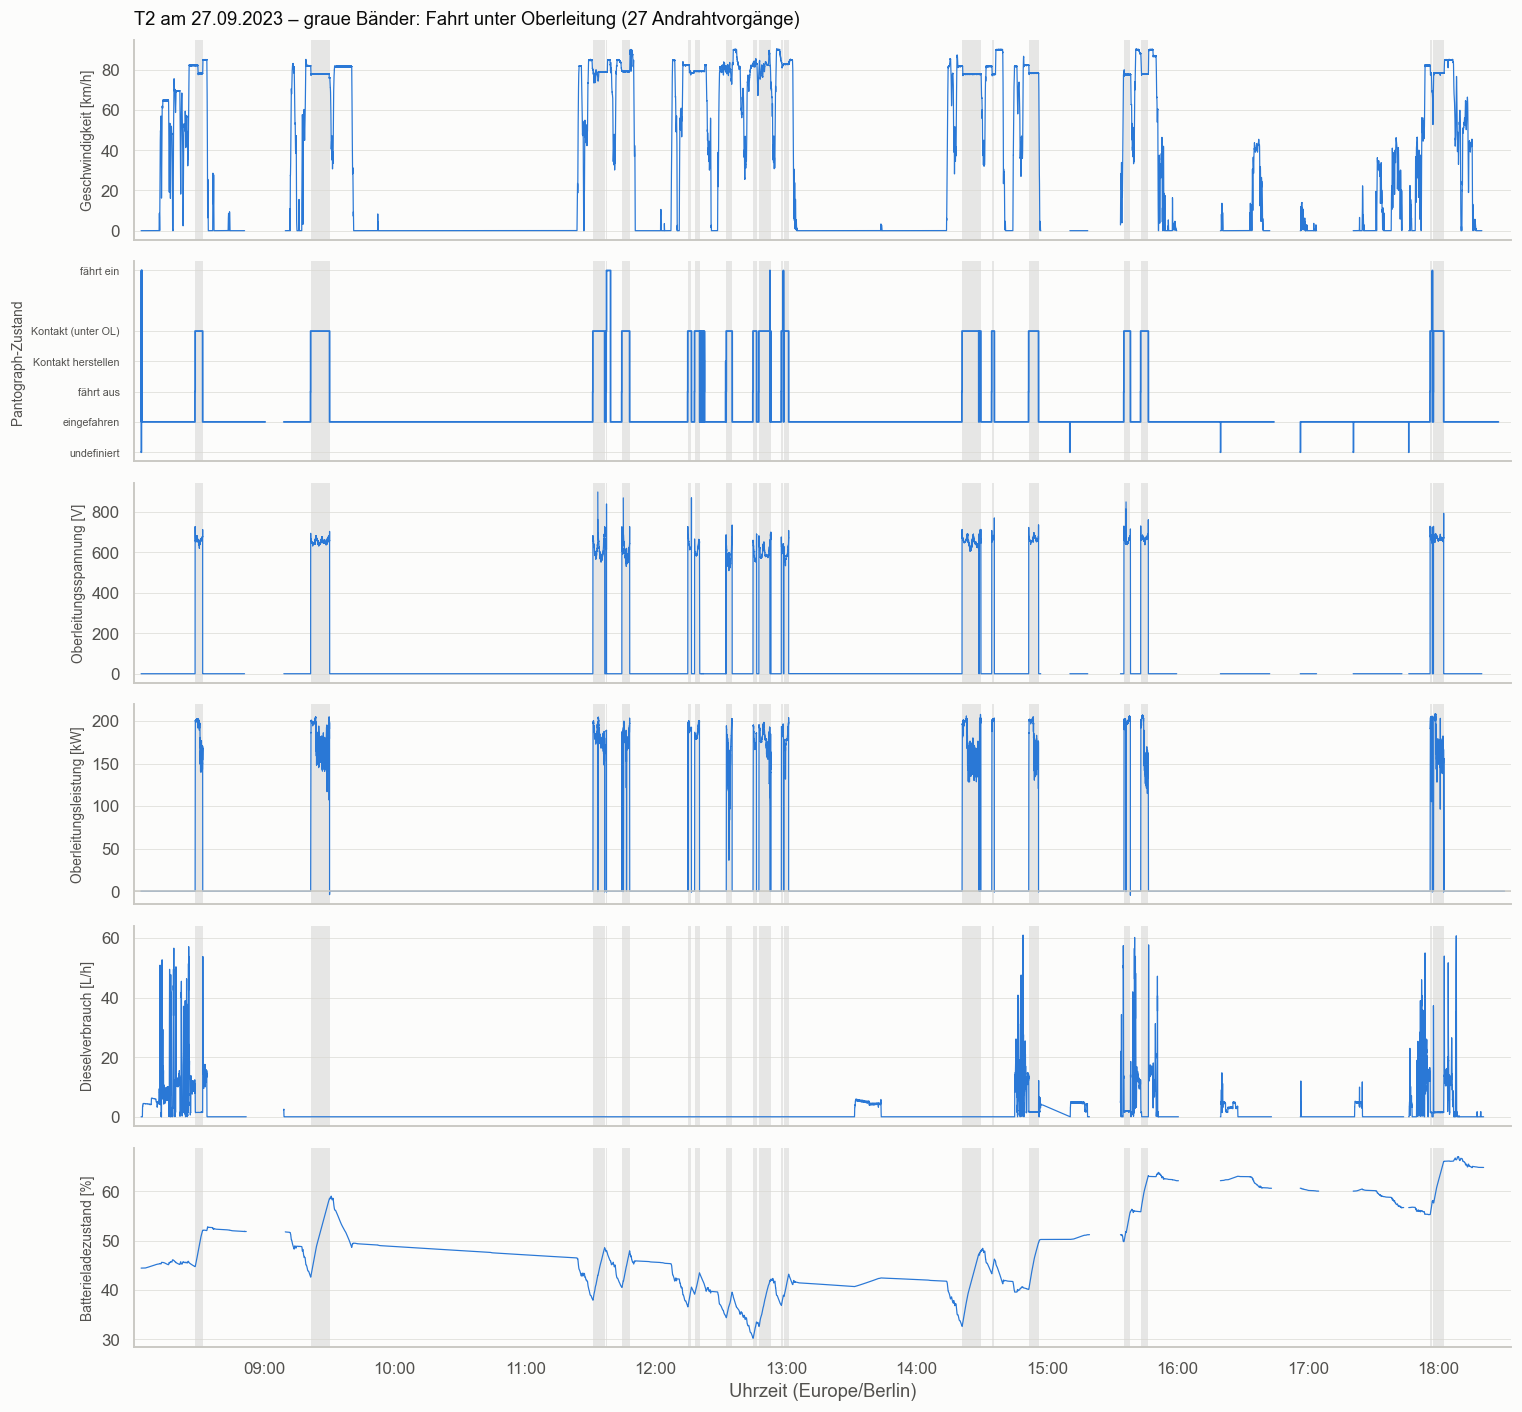

In [15]:
panels = [
    ("WheelBasedVehicleSpeed (km/h)", "Geschwindigkeit [km/h]", None),
    ("PantographActualStatus",        "Pantograph-Zustand",     "step"),
    ("MeasuredOclVoltage",            "Oberleitungsspannung [V]", None),
    ("P_ocl_kW",                      "Oberleitungsleistung [kW]", None),
    ("FuelRate (L/h)",                "Dieselverbrauch [L/h]",  None),
    ("BatterySOC",                    "Batterieladezustand [%]", None),
]

fig, axes = plt.subplots(len(panels), 1, figsize=(14, 13), sharex=True)
t = day["t_local"]

for ax, (col, label, kind) in zip(axes, panels):
    if kind == "step":
        ax.step(t, day[col], where="post", color=SERIES[0], linewidth=1.2)
        ax.set_yticks(sorted(PANTO_LABELS))
        ax.set_yticklabels([PANTO_LABELS[k] for k in sorted(PANTO_LABELS)], fontsize=7)
    else:
        ax.plot(t, day[col], color=SERIES[0], linewidth=0.8)
    if col == "P_ocl_kW":
        ax.axhline(0, color="#c9c8c3", linewidth=1)
    for s, e in runs:                                    # Kontaktphasen hinterlegen
        ax.axvspan(s, e, color="#0b0b0b", alpha=0.09, linewidth=0, zorder=0)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis="x", visible=False)
    ax.margins(x=0.005)

axes[0].set_title(f"T2 am {DAY:%d.%m.%Y} – graue Bänder: Fahrt unter Oberleitung "
                  f"({len(runs)} Andrahtvorgänge)", color=INK)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=t.dt.tz))
axes[-1].set_xlabel("Uhrzeit (Europe/Berlin)")
plt.tight_layout()
plt.show()

Die Kopplung der Signale ist eindeutig: Sobald der Pantograph auf **Kontakt (Code 4)** springt,
steigt die Oberleitungsspannung auf ~670 V, die bezogene Leistung auf 150–210 kW – und der
**Dieselverbrauch fällt praktisch auf null**. Der Ladezustand der Batterie steigt in diesen Phasen
(Rekuperation + Nachladen aus der Oberleitung) und sinkt danach wieder.

Gut zu erkennen ist außerdem der **Pendelverkehr**: Der Lkw fährt den elektrifizierten Abschnitt an diesem
Tag 27-mal ab – die grauen Bänder folgen einem regelmäßigen Takt.

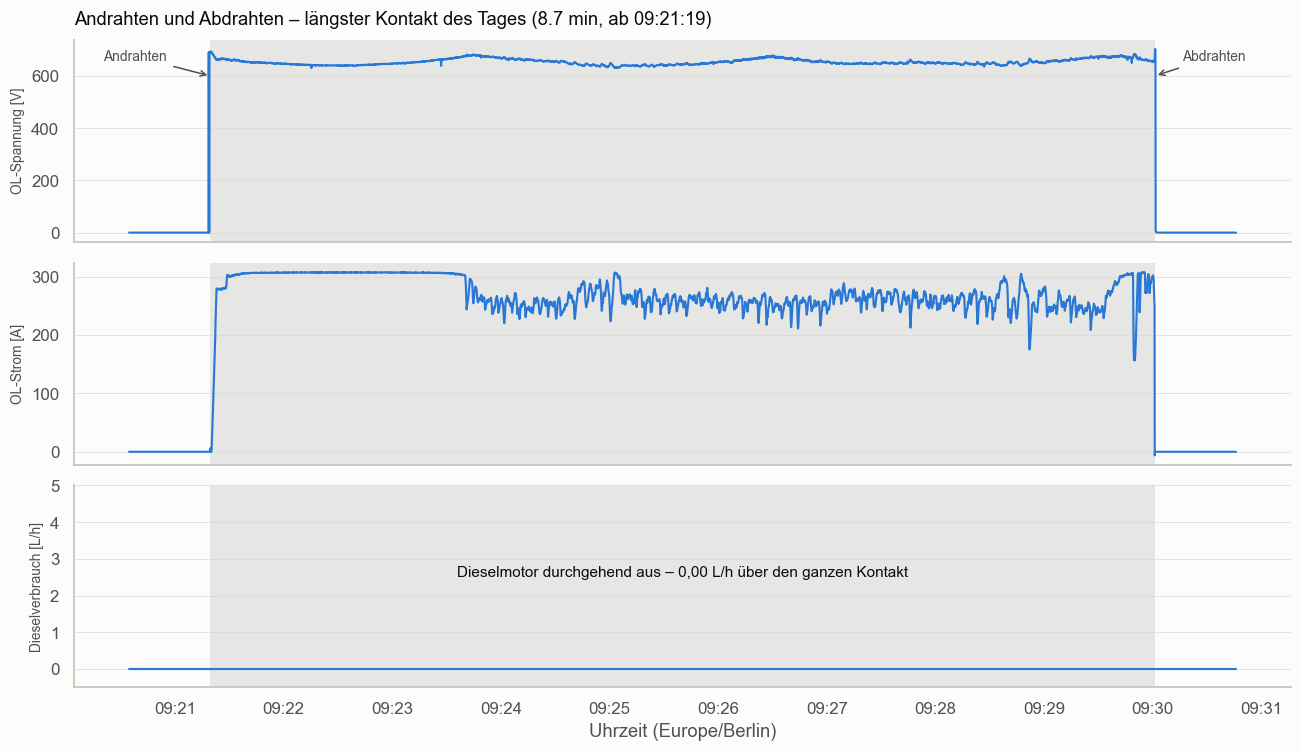

In [16]:
# Zoom auf einen einzelnen An-/Abdrahtvorgang (der längste des Tages)
lens = [(e - s).total_seconds() for s, e in runs]
i = int(np.argmax(lens))
s, e = runs[i]
pad = pd.Timedelta(seconds=45)
z = day[(day["t_local"] >= s - pad) & (day["t_local"] <= e + pad)]

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, (col, label) in zip(axes, [("MeasuredOclVoltage", "OL-Spannung [V]"),
                                   ("MeasuredOclCurrent", "OL-Strom [A]"),
                                   ("FuelRate (L/h)", "Dieselverbrauch [L/h]")]):
    ax.plot(z["t_local"], z[col], color=SERIES[0], linewidth=1.4)
    ax.axvspan(s, e, color="#0b0b0b", alpha=0.09, linewidth=0, zorder=0)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis="x", visible=False)

# Der Verbrauch ist über den gesamten Kontakt exakt 0 -> feste Achse, sonst
# spreizt matplotlib eine Pseudo-Skala von -0,04 bis +0,04 auf.
fuel_max = float(z["FuelRate (L/h)"].max())
axes[2].set_ylim(-0.5, max(fuel_max * 1.2, 5))
if fuel_max == 0:
    axes[2].annotate("Dieselmotor durchgehend aus – 0,00 L/h über den ganzen Kontakt",
                     xy=(0.5, 0.55), xycoords="axes fraction", ha="center",
                     fontsize=10, color=INK)

axes[0].set_title(f"Andrahten und Abdrahten – längster Kontakt des Tages "
                  f"({lens[i]/60:.1f} min, ab {s:%H:%M:%S})", color=INK)
axes[0].annotate("Andrahten", xy=(s, 600), xytext=(-70, 10), textcoords="offset points",
                 fontsize=9, color=INK2, arrowprops=dict(arrowstyle="->", color=INK2, lw=1))
axes[0].annotate("Abdrahten", xy=(e, 600), xytext=(18, 10), textcoords="offset points",
                 fontsize=9, color=INK2, arrowprops=dict(arrowstyle="->", color=INK2, lw=1))
axes[-1].xaxis.set_major_locator(mdates.MinuteLocator(interval=1, tz=z["t_local"].dt.tz))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=z["t_local"].dt.tz))
axes[-1].set_xlabel("Uhrzeit (Europe/Berlin)")
plt.tight_layout()
plt.show()

## 6. Pantograph-Nutzung und Energiebilanz

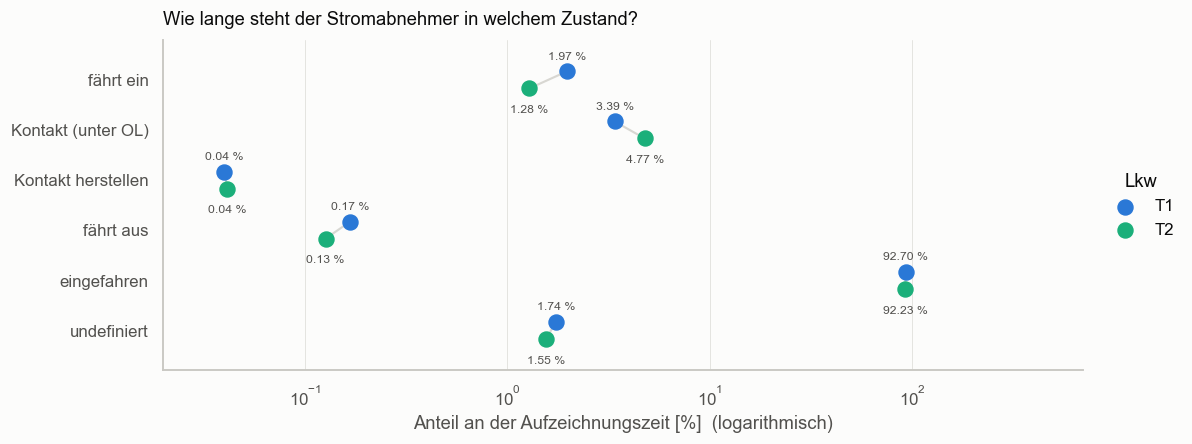

In [17]:
# Zeitanteile der Pantograph-Zustände über die gesamte Flotte (1-Hz-Datensatz)
share = (hz1_df.groupby(["Lkw", "PantographActualStatus"])["dt_s"].count()
               .unstack(0).fillna(0))
share = share / share.sum() * 100
share.index = [PANTO_LABELS.get(int(i), f"Code {int(i)}") for i in share.index]


# Die Anteile umspannen vier Größenordnungen (97 % vs. 0,01 %). Ein Balkendiagramm
# mit logarithmischer Achse wäre irreführend (Balkenlänge ohne sinnvollen Nullpunkt),
# deshalb ein Punktdiagramm: hier kodiert die POSITION, nicht die Länge.
fig, ax = plt.subplots(figsize=(11, 4.2))
y = np.arange(len(share))
off = 0.17                                    # Hantel-Versatz: sonst verdecken sich gleiche Werte
for yy in y:                                  # Verbindungslinie T1 <-> T2
    ax.plot([share["T1"].iloc[yy], share["T2"].iloc[yy]], [yy + off, yy - off],
            color="#d8d7d2", linewidth=1.4, zorder=2)
for i, tr in enumerate(["T1", "T2"]):
    v = share[tr].replace(0, np.nan)
    yy = y + (off if i == 0 else -off)
    ax.scatter(v, yy, s=95, color=SERIES[i], label=tr, zorder=3)
    # T1 (obere Reihe) beschriftet nach oben, T2 nach unten -- sonst kollidiert
    # das Label der einen Serie mit dem Punkt der anderen
    dy = 8 if i == 0 else -16
    for a, b in zip(v, yy):
        if pd.notna(a):
            ax.annotate(f"{a:.2f} %", (a, b), xytext=(0, dy), textcoords="offset points",
                        ha="center", fontsize=8, color=INK2)

ax.set_yticks(y); ax.set_yticklabels(share.index)
ax.set_xlabel("Anteil an der Aufzeichnungszeit [%]  (logarithmisch)")
ax.set_xscale("log"); ax.set_xlim(0.02, 700)
ax.set_ylim(-0.8, len(share) - 0.2)
ax.set_title("Wie lange steht der Stromabnehmer in welchem Zustand?", color=INK)
ax.grid(axis="y", visible=False)
ax.legend(title="Lkw", loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

In [18]:
# Energiebilanz an der Oberleitung
energy = overview.groupby("Lkw").agg(**{
    "km gesamt": ("km", "sum"),
    "km unter OL": ("km unter OL", "sum"),
    "Diesel L": ("Diesel L", "sum"),
    "E Bezug kWh": ("E_OL kWh (Bezug)", "sum"),
    "E Rekup. kWh": ("E_OL kWh (Rekup.)", "sum"),
})
energy["OL-Anteil %"] = energy["km unter OL"] / energy["km gesamt"] * 100
energy["kWh/km unter OL"] = energy["E Bezug kWh"] / energy["km unter OL"]
energy["Rekup.-Quote %"] = energy["E Rekup. kWh"] / energy["E Bezug kWh"] * 100
energy["L/100km gesamt"] = energy["Diesel L"] / energy["km gesamt"] * 100
energy.round(2)

,km gesamt,km unter OL,Diesel L,E Bezug kWh,E Rekup. kWh,OL-Anteil %,kWh/km unter OL,Rekup.-Quote %,L/100km gesamt
Lkw,,,,,,,,,
T1,5404.310059,304.559998,1428.79,282.57,3.32,5.64,0.93,1.18,26.44
T2,5695.439941,572.919983,957.54,1312.47,0.00,10.06,2.29,0.00,16.81


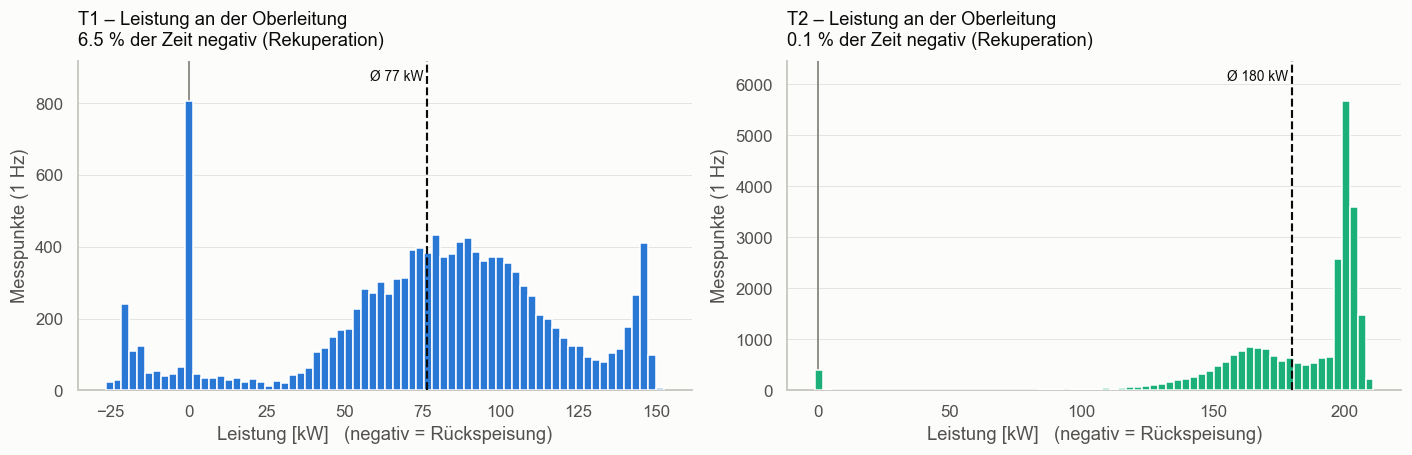

In [19]:
# Verteilung der Oberleitungsleistung, getrennt nach Fahrzeug
cat_hz1 = hz1_df[hz1_df["catenary"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, tr, colr in zip(axes, ["T1", "T2"], SERIES[:2]):
    v = cat_hz1.loc[cat_hz1["Lkw"] == tr, "P_ocl_kW"].dropna()
    ax.hist(v, bins=70, color=colr, zorder=3)
    ax.margins(y=0.14)
    ax.axvline(0, color="#8a8981", linewidth=1.2)
    ax.axvline(v.mean(), color=INK, linewidth=1.4, linestyle="--", zorder=4)
    # Beschriftung nach links von der Linie -- rechts davon liegt bei T2 der hohe Peak
    ax.annotate(f"Ø {v.mean():.0f} kW ", xy=(v.mean(), 1.0), xycoords=("data", "axes fraction"),
                xytext=(0, -13), textcoords="offset points", ha="right", fontsize=9, color=INK)
    neg = (v < 0).mean() * 100
    ax.set_title(f"{tr} – Leistung an der Oberleitung\n"
                 f"{neg:.1f} % der Zeit negativ (Rekuperation)", color=INK)
    ax.set_xlabel("Leistung [kW]   (negativ = Rückspeisung)")
    ax.set_ylabel("Messpunkte (1 Hz)")
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

`T1` speist in **6,5 %** der Kontaktzeit Bremsenergie in die Oberleitung zurück (bis −26,6 kW); über die
Energiebilanz sind das **1,18 %** der bezogenen Energie. `T2` rekuperiert praktisch nie ins Netz (0,1 % der
Zeit, Minimum −1,1 kW). Dafür bezieht `T2` mit **Ø 180 kW** mehr als das
Doppelte von `T1` (**Ø 76,5 kW**): zwei E-Motoren plus paralleles Nachladen unter Draht.

Die Kennzahl **kWh/km unter Oberleitung** ist entsprechend für `T2` (**2,29**) rund 2,5-mal so hoch wie für
`T1` (**0,93**). Sie ist **kein Wirkungsgrad**: Sie enthält auch die Energie, die in die Batterie wandert und
später außerhalb des elektrifizierten Abschnitts genutzt wird.

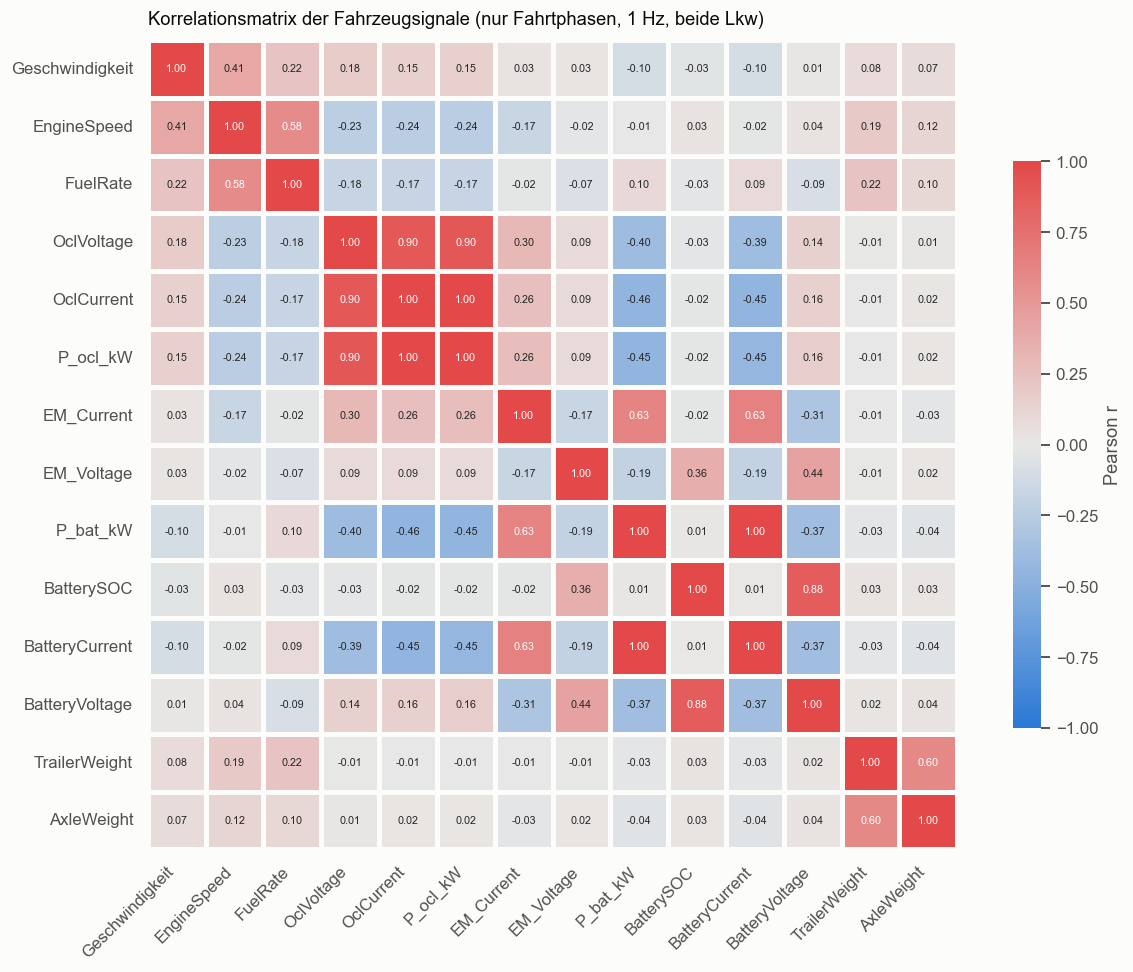

In [20]:
# Korrelationsstruktur der Signale (nur Fahrtphasen, 1 Hz)
corr_cols = ["WheelBasedVehicleSpeed (km/h)", "EngineSpeed (rpm)", "FuelRate (L/h)",
             "MeasuredOclVoltage", "MeasuredOclCurrent", "P_ocl_kW",
             "EM_Current (A)", "EM_Voltage (V)", "P_bat_kW",
             "BatterySOC", "BatteryCurrent", "BatteryVoltage",
             "TrailerWeight (kg)", "AxleWeight (kg)"]

moving = hz1_df[hz1_df["moving"]]
corr = moving[corr_cols].corr()
labels = [c.replace(" (km/h)", "").replace(" (rpm)", "").replace(" (A)", "")
           .replace(" (V)", "").replace(" (L/h)", "").replace(" (kg)", "")
           .replace("Measured", "").replace("WheelBasedVehicleSpeed", "Geschwindigkeit")
          for c in corr_cols]

fig, ax = plt.subplots(figsize=(11.5, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=CMAP_DIV, center=0, vmin=-1, vmax=1,
            square=True, linewidths=2, linecolor=SURFACE, ax=ax,
            xticklabels=labels, yticklabels=labels,
            annot_kws={"fontsize": 7}, cbar_kws={"label": "Pearson r", "shrink": 0.7})
ax.set_title("Korrelationsmatrix der Fahrzeugsignale (nur Fahrtphasen, 1 Hz, beide Lkw)", color=INK)
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Ablesbar sind vor allem drei Blöcke:

* **`OclVoltage` ↔ `OclCurrent` ↔ `P_ocl`** korrelieren stark miteinander – sie beschreiben denselben
  physikalischen Vorgang (Kontakt ja/nein).
* **`EngineSpeed` ↔ `FuelRate`** hängen erwartungsgemäß eng zusammen; beide korrelieren *negativ* mit der
  Oberleitungsleistung: Wo Strom fließt, läuft der Diesel nicht.
* **`TrailerWeight` ↔ `AxleWeight`** messen beide die Beladung.

Die Korrelationen sind Assoziationen, keine Kausalität – für die eigentliche Frage (senkt die Oberleitung
den Verbrauch?) braucht es einen sauberen Gruppenvergleich.

## 7. Hypothesentest 1: Senkt die Oberleitung den Dieselverbrauch?

### Methodische Vorüberlegung

Ein naiver Test auf den 10-Hz-Rohdaten (≈ 9,4 Mio. Zeilen) liefert immer `p ≈ 0` – aber das Ergebnis wäre
wertlos: Aufeinanderfolgende Messpunkte im Abstand von 0,1 s sind **hochgradig autokorreliert** und keine
unabhängigen Stichproben (*Pseudo-Replikation*). Die effektive Stichprobengröße ist um Größenordnungen
kleiner als die Zeilenzahl.

Deshalb wird auf **unabhängige Fahrtblöcke** aggregiert (`extract_blocks`, Kapitel 4):

* nur **Autobahn-Fahrt** (v > 70 km/h) – damit Stadt-, Rangier- und Standphasen den Vergleich nicht verzerren,
* je Block **genau ein Betriebsmodus** (Oberleitung / Diesel), Blockwechsel auch bei Datenlücken > 2 s,
* **mindestens 30 s** Dauer,
* Kennwert je Block: **mittlerer Verbrauch in L/h**.

Verglichen wird **je Fahrzeug getrennt** (T1 und T2 sind bauartverschieden).

**Test:** Mann-Whitney-U (Wilcoxon-Rangsummentest), zweiseitig, α = 0,05 – nicht-parametrisch, da die
Verbrauchsverteilungen deutlich schief sind (viele Nullwerte bei Motor-Aus).

- **H₀:** Der mediane Verbrauch [L/h] unterscheidet sich nicht zwischen Oberleitungs- und Dieselfahrt.
- **H₁:** Er unterscheidet sich.

In [21]:
# Kontrolle: sind die Blöcke vergleichbar (ähnliche Geschwindigkeit)?
ctrl = (blocks_df.groupby(["Lkw", "Modus"])
                 .agg(Blöcke=("n", "size"),
                      Dauer_min=("Dauer_s", lambda s: s.sum()/60),
                      Geschw_kmh=("Geschw_kmh", "mean"),
                      Verbrauch_Median=("Verbrauch_L_h", "median"),
                      Verbrauch_Mittel=("Verbrauch_L_h", "mean"),
                      Motor_aus_pct=("Motor_aus_pct", "mean"))
                 .round(2))
ctrl

Blöcke  Dauer_min  Geschw_kmh  Verbrauch_Median  Verbrauch_Mittel  Motor_aus_pct
Lkw Modus                                                                                        
T1  Diesel          456    2301.02   83.419998         19.370001             19.84          10.22
    Oberleitung      79     212.24   83.019997          2.030000              2.55          14.07
T2  Diesel          716    2521.03   80.480003         12.970000             12.68          17.68
    Oberleitung     142     430.79   79.059998          1.490000              1.29          36.92

In [22]:
from scipy.stats import mannwhitneyu

alpha = 0.05
results = []

print("Hypothesentest 1: Oberleitung vs. Diesel (Autobahnfahrt > 70 km/h)\n" + "="*70)
for tr in ["T1", "T2"]:
    sub = blocks_df[blocks_df["Lkw"] == tr]
    is_ol = sub["Modus"] == "Oberleitung"
    ol = sub.loc[is_ol, "Verbrauch_L_h"]
    di = sub.loc[~is_ol, "Verbrauch_L_h"]
    v_ol = sub.loc[is_ol, "Geschw_kmh"].mean()
    v_di = sub.loc[~is_ol, "Geschw_kmh"].mean()

    u, p = mannwhitneyu(ol, di, alternative="two-sided")
    # Effektstärke: Rangbiserialer Korrelationskoeffizient  r = 1 - 2U/(n1*n2)
    r_rb = 1 - 2 * u / (len(ol) * len(di))
    red = (1 - ol.median() / di.median()) * 100

    print(f"\n{tr}:")
    print(f"  Blöcke              : Oberleitung n = {len(ol):3d}   |  Diesel n = {len(di):4d}")
    print(f"  Ø Geschwindigkeit   : {v_ol:.1f} km/h            |  {v_di:.1f} km/h   (vergleichbar)")
    print(f"  Median Verbrauch    : {ol.median():6.2f} L/h        |  {di.median():6.2f} L/h")
    print(f"  Mann-Whitney U      : {u:,.1f}")
    print(f"  p-Wert              : {p:.3g}")
    print(f"  Effektstärke (r_rb) : {r_rb:.3f}   (|r| > 0,5 = großer Effekt)")
    if p < alpha:
        print(f"  => p < {alpha}: H0 verworfen – der Verbrauch sinkt unter Oberleitung um "
              f"{red:.1f} % (Median).")
    else:
        print(f"  => p >= {alpha}: H0 beibehalten.")

    results.append({"Lkw": tr, "n_OL": len(ol), "n_Diesel": len(di),
                    "Median_OL": ol.median(), "Median_Diesel": di.median(),
                    "U": u, "p": p, "r_rb": r_rb, "Reduktion_%": red})

results_df = pd.DataFrame(results)

Hypothesentest 1: Oberleitung vs. Diesel (Autobahnfahrt > 70 km/h)

T1:
  Blöcke              : Oberleitung n =  79   |  Diesel n =  456
  Ø Geschwindigkeit   : 83.0 km/h            |  83.4 km/h   (vergleichbar)
  Median Verbrauch    :   2.03 L/h        |   19.37 L/h
  Mann-Whitney U      : 493.0
  p-Wert              : 2.2e-43
  Effektstärke (r_rb) : 0.973   (|r| > 0,5 = großer Effekt)
  => p < 0.05: H0 verworfen – der Verbrauch sinkt unter Oberleitung um 89.5 % (Median).

T2:
  Blöcke              : Oberleitung n = 142   |  Diesel n =  716
  Ø Geschwindigkeit   : 79.1 km/h            |  80.5 km/h   (vergleichbar)
  Median Verbrauch    :   1.49 L/h        |   12.97 L/h
  Mann-Whitney U      : 11,564.0
  p-Wert              : 4e-48
  Effektstärke (r_rb) : 0.773   (|r| > 0,5 = großer Effekt)
  => p < 0.05: H0 verworfen – der Verbrauch sinkt unter Oberleitung um 88.5 % (Median).


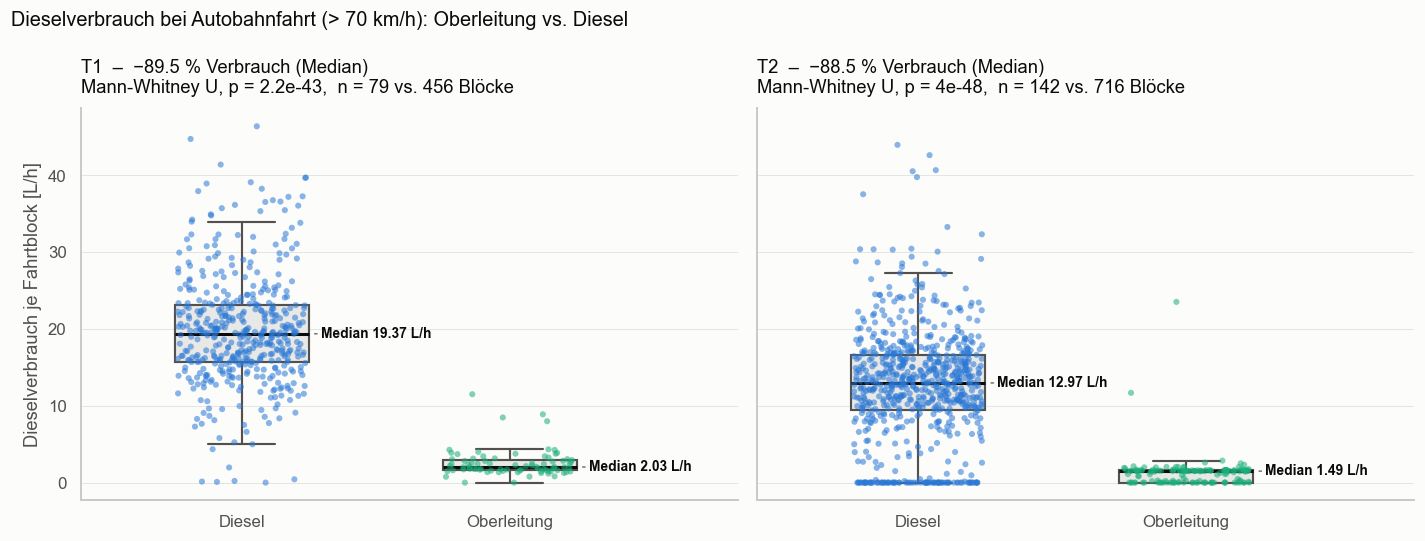

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
order = ["Diesel", "Oberleitung"]

for ax, tr in zip(axes, ["T1", "T2"]):
    sub = blocks_df[blocks_df["Lkw"] == tr]
    sns.boxplot(data=sub, x="Modus", y="Verbrauch_L_h", order=order, ax=ax,
                width=0.5, showfliers=False, linewidth=1.4,
                boxprops=dict(facecolor="#e8e8e6", edgecolor=INK2),
                medianprops=dict(color=INK, linewidth=2),
                whiskerprops=dict(color=INK2), capprops=dict(color=INK2))
    sns.stripplot(data=sub, x="Modus", y="Verbrauch_L_h", order=order, ax=ax,
                  hue="Modus", palette={"Diesel": SERIES[0], "Oberleitung": SERIES[1]},
                  size=4, alpha=0.55, jitter=0.24, legend=False, zorder=3)
    # Direkte Beschriftung der Mediane (Pflicht bei Slot-2-Kontrast < 3:1);
    # rechts neben der Box platziert, damit sie Box und Whisker nicht überdeckt
    for i, mo in enumerate(order):
        m = sub.loc[sub["Modus"] == mo, "Verbrauch_L_h"].median()
        ax.annotate(f"Median {m:.2f} L/h", xy=(i + 0.26, m), xytext=(6, 0),
                    textcoords="offset points", va="center", ha="left", fontsize=9,
                    color=INK, fontweight="bold",
                    arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8, shrinkA=0, shrinkB=2))
    ax.set_xlim(-0.6, 1.85)

    res = results_df[results_df["Lkw"] == tr].iloc[0]
    ax.set_title(f"{tr}  –  −{res['Reduktion_%']:.1f} % Verbrauch (Median)\n"
                 f"Mann-Whitney U, p = {res['p']:.2g},  n = {res['n_OL']} vs. {res['n_Diesel']} Blöcke",
                 color=INK)
    ax.set_xlabel(""); ax.grid(axis="x", visible=False)

axes[0].set_ylabel("Dieselverbrauch je Fahrtblock [L/h]")
fig.suptitle("Dieselverbrauch bei Autobahnfahrt (> 70 km/h): Oberleitung vs. Diesel",
             x=0.005, ha="left", fontsize=13, color=INK)
plt.tight_layout()
plt.show()

### Interpretation

| Lkw | Vergleich | n (OL vs. Diesel) | Median OL | Median Diesel | U | p | Effekt r_rb | Ergebnis (α = 0,05) |
|---|---|---|---|---|---|---|---|---|
| T1 | Oberleitung vs. Diesel | 79 vs. 456 | 2,03 L/h | 19,37 L/h | 493 | 2,2 · 10⁻⁴³ | 0,97 | **signifikant** |
| T2 | Oberleitung vs. Diesel | 142 vs. 716 | 1,49 L/h | 12,97 L/h | 11 564 | 4,0 · 10⁻⁴⁸ | 0,77 | **signifikant** |

*(Der rangbiseriale Koeffizient `r_rb = 1 − 2U/(n₁n₂)` ist hier positiv, weil die Oberleitungsblöcke fast
durchweg **niedriger** rangieren als die Dieselblöcke: bei T1 verbraucht praktisch jeder Oberleitungsblock
weniger als jeder Dieselblock.)*

**Fazit:** H₀ wird für beide Fahrzeuge klar verworfen. Der Median-Dieselverbrauch sinkt unter Oberleitung
um **89,5 %** (T1) bzw. **88,5 %** (T2). Die mittlere Geschwindigkeit der verglichenen Blöcke ist mit
83,0 vs. 83,4 km/h (T1) und 79,1 vs. 80,5 km/h (T2) nahezu identisch – der Effekt lässt sich also nicht
durch unterschiedliche Fahrprofile erklären. Die Effektstärke ist in beiden Fällen sehr groß.

**Warum nicht 100 %?** Der Restverbrauch von 1,5–2 L/h stammt aus Phasen, in denen der Dieselmotor unter
Oberleitung **weiterläuft** (Leerlauf, Nebenverbraucher, Lastspitzen). `T2` schaltet den Motor in
**36,9 %** der Oberleitungszeit ganz ab, `T1` nur in **14,1 %** – ein Hinweis auf unterschiedliche
Betriebsstrategien der beiden Fahrzeuge.

### Einschränkungen

* **Kein randomisiertes Experiment.** Die Oberleitung existiert nur auf ~5 km je Richtung zwischen
  Zeppelinheim und Weiterstadt. „Oberleitungsblöcke" liegen damit systematisch auf *diesem* Streckenstück
  (flach, konstante Geschwindigkeit), Dieselblöcke auf der ganzen A5. Steigungen, Verkehr und Beladung sind
  nicht kontrolliert. Der Geschwindigkeitsabgleich mindert diesen Confounder, beseitigt ihn aber nicht.
* Der Vergleich misst den Verbrauch **während** der Oberleitungsfahrt. Die Ersparnis über einen ganzen
  Umlauf ist kleiner, weil nur 4–20 % der Kilometer unter Draht liegen (vgl. Kapitel 4).
* Die Blöcke eines Tages sind untereinander nicht vollständig unabhängig (gleicher Fahrer, gleiche Ladung).
  Der p-Wert ist daher eher optimistisch – bei r ≈ −0,8 … −0,97 ändert das an der Schlussfolgerung nichts.

## 8. Unfalldaten der A5 (2024)

Der zweite Datensatz stammt aus dem **Unfallatlas der statistischen Ämter** und enthält alle
polizeilich erfassten Unfälle auf der **A5 in Hessen** im Jahr 2024. Die Spaltennamen folgen dem
amtlichen Schlüsselverzeichnis.

**Fallstrick bei den Koordinaten:** `X` und `Y` sind Festkomma-Ganzzahlen *ohne* Dezimalpunkt, und die
Anzahl der Nachkommastellen variiert (7–10 Ziffern), weil abschließende Nullen verloren gegangen sind.
Ein pauschales `/1e8` liefert für 61 Zeilen Koordinaten wie `0,0859` statt `8,59`. Robuster ist es,
solange durch 10 zu teilen, bis der Wert im gültigen Bereich liegt.

In [24]:
acc = pd.read_excel(EXCEL_PATH)
print(f"{len(acc):,} Unfälle, {acc.shape[1]} Spalten   |   Straße(n): "
      f"{sorted(acc.USTRNR.unique())}  (5 = A5)")


def fix_coord(series, upper):
    """Festkomma-Ganzzahl -> Dezimalgrad (variable Stellenzahl)."""
    v = series.astype(float).copy()
    for _ in range(12):
        m = v > upper
        if not m.any():
            break
        v[m] /= 10
    return v


acc["lon"] = fix_coord(acc["X"], 10.0)     # Längengrad Hessen: 8–10 °O
acc["lat"] = fix_coord(acc["Y"], 51.0)     # Breitengrad Hessen: 49–51 °N

print(f"\nvorher  (naives /1e8): lon {acc.X.min()/1e8:.4f} … {acc.X.max()/1e8:.4f}")
print(f"nachher (skaliert)   : lon {acc.lon.min():.4f} … {acc.lon.max():.4f}   "
      f"lat {acc.lat.min():.4f} … {acc.lat.max():.4f}")
print(f"Ziffernlängen X: {acc.X.astype(str).str.len().value_counts().to_dict()}")

734 Unfälle, 55 Spalten   |   Straße(n): [np.int64(5)]  (5 = A5)

vorher  (naives /1e8): lon 0.0859 … 9.5422
nachher (skaliert)   : lon 8.5142 … 9.5422   lat 49.6169 … 50.8127
Ziffernlängen X: {9: 663, 8: 61, 7: 10}


In [25]:
KAT = {1: "mit Getöteten", 2: "mit Schwerverletzten", 3: "mit Leichtverletzten", 4: "nur Sachschaden"}
WOCHENTAG = {1: "So", 2: "Mo", 3: "Di", 4: "Mi", 5: "Do", 6: "Fr", 7: "Sa"}

acc["Kategorie"] = acc["UKATEGORIE"].map(KAT)
acc["LKW_beteiligt"] = acc["LKW"] > 0
acc["Personenschaden"] = acc["UKATEGORIE"].isin([1, 2, 3])
acc["schwer_oder_toedlich"] = acc["UKATEGORIE"].isin([1, 2])
acc["Stunde"] = acc["USTUNDE"]
acc["Wochentag"] = acc["UWOCHENTAG"].map(WOCHENTAG)

print("Unfallkategorien:")
print(acc.groupby("Kategorie").agg(
    Unfälle=("UKATEGORIE", "size"), Getötete=("UANZGETOE", "sum"),
    Schwerverletzte=("UANZSCHWER", "sum"), Leichtverletzte=("UANZLEICHT", "sum"),
    Beteiligte=("UANZBET", "sum"), mit_LKW=("LKW_beteiligt", "sum")).to_string())

print(f"\nInsgesamt: {int(acc.UANZGETOE.sum())} Getötete, {int(acc.UANZSCHWER.sum())} Schwer- "
      f"und {int(acc.UANZLEICHT.sum())} Leichtverletzte")
print(f"Lkw beteiligt: {acc.LKW_beteiligt.sum()} von {len(acc)} Unfällen "
      f"({acc.LKW_beteiligt.mean()*100:.1f} %)")

Unfallkategorien:
                      Unfälle  Getötete  Schwerverletzte  Leichtverletzte  Beteiligte  mit_LKW
Kategorie                                                                                     
mit Getöteten               8       9.0              4.0              0.0          36        5
mit Leichtverletzten      384       0.0              0.0            601.0         900       78
mit Schwerverletzten       53       0.0             63.0             54.0         129       24
nur Sachschaden           289       0.0              0.0              0.0         523       83

Insgesamt: 9 Getötete, 67 Schwer- und 655 Leichtverletzte
Lkw beteiligt: 190 von 734 Unfällen (25.9 %)


In [31]:
import folium

# Näherungsweiser ELISA-Oberleitungsabschnitt (AS Zeppelinheim <-> AS Weiterstadt)
ELISA_BOX = dict(lat=(49.90, 50.02), lon=(8.50, 8.68))

m = folium.Map(location=[50.15, 8.8], zoom_start=8, tiles="CartoDB positron")

# Der elektrifizierte Abschnitt
folium.Rectangle(
    bounds=[[ELISA_BOX["lat"][0], ELISA_BOX["lon"][0]], [ELISA_BOX["lat"][1], ELISA_BOX["lon"][1]]],
    color=SERIES[1], weight=2, fill=True, fill_opacity=0.10,
    tooltip="ELISA-Oberleitungsabschnitt (Näherung)",
).add_to(m)

# Unfälle, eingefärbt nach Schwere (ordinale Rampe: heltl = leicht, dunkel = tödlich)
ORD = {4: RAMP_ORD[0], 3: RAMP_ORD[1], 2: RAMP_ORD[2], 1: RAMP_ORD[3]}
for kat in [4, 3, 2, 1]:
    fg = folium.FeatureGroup(name=f"{KAT[kat]} (n={int((acc.UKATEGORIE==kat).sum())})",
                             show=(kat <= 2))
    for _, r in acc[acc.UKATEGORIE == kat].iterrows():
        folium.CircleMarker(
            [r.lat, r.lon], radius=3 + (4 - kat) * 1.4,
            color=ORD[kat], fill=True, fill_color=ORD[kat], fill_opacity=0.75, weight=0.6,
            tooltip=(f"{KAT[kat]}<br>{int(r.UTAG):02d}.{int(r.UMONAT):02d}.2024, "
                     f"{int(r.USTUNDE):02d} Uhr<br>"
                     f"Lkw beteiligt: {'ja' if r.LKW_beteiligt else 'nein'}"),
        ).add_to(fg)
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

Die Karte zeigt die A5 von Basel-Richtung (unten, Bergstraße) über das Frankfurter Kreuz bis zum
Hattenbacher Dreieck (oben). Das grüne Rechteck markiert näherungsweise den **ELISA-Oberleitungsabschnitt**.
Standardmäßig sind nur die schweren und tödlichen Unfälle eingeblendet – die übrigen Ebenen lassen sich
über die Legende oben rechts zuschalten.

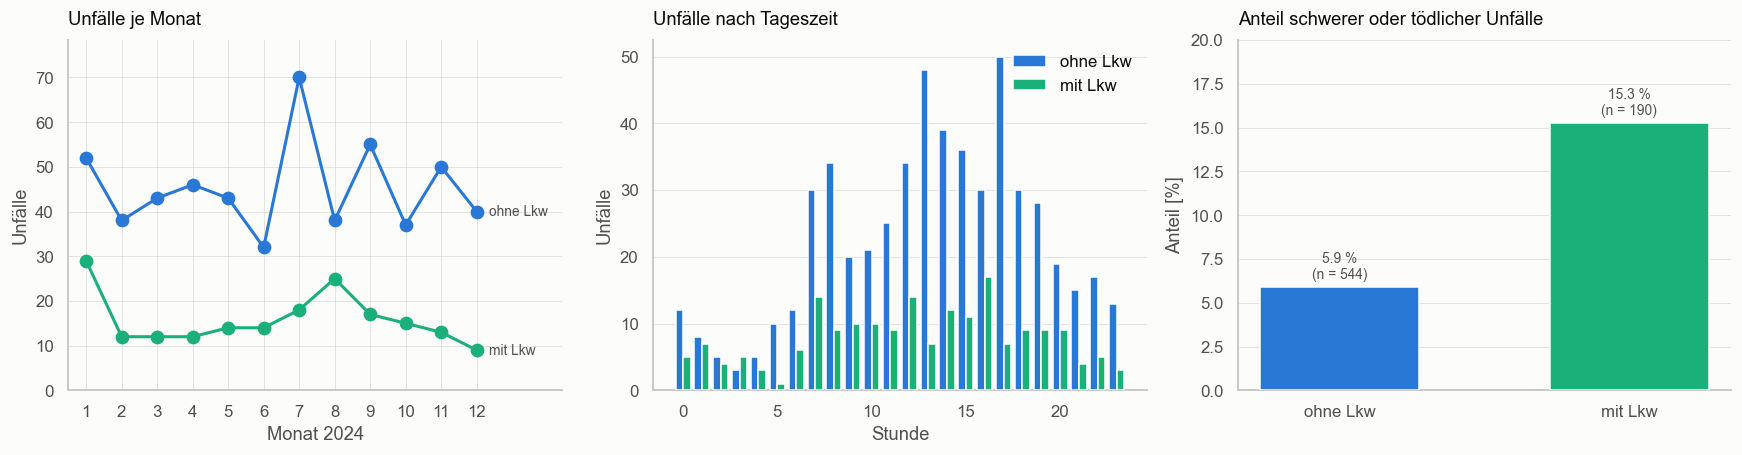

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

# (a) Unfälle je Monat, getrennt nach Lkw-Beteiligung
# Direkte Beschriftung am Linienende statt Legende (bei 2 Serien lesbarer)
mon = acc.groupby(["UMONAT", "LKW_beteiligt"]).size().unstack(fill_value=0)
for i, (col, lab) in enumerate([(False, "ohne Lkw"), (True, "mit Lkw")]):
    axes[0].plot(mon.index, mon[col], marker="o", color=SERIES[i], label=lab)
    axes[0].annotate(lab, (mon.index[-1], mon[col].iloc[-1]), xytext=(8, 0),
                     textcoords="offset points", fontsize=9, color=INK2, va="center")
axes[0].set_title("Unfälle je Monat", color=INK)
axes[0].set_xlabel("Monat 2024"); axes[0].set_ylabel("Unfälle")
axes[0].set_xticks(range(1, 13))
axes[0].set_xlim(0.5, 14.4)     # Platz für die Endbeschriftungen
axes[0].set_ylim(0, mon.values.max() * 1.12)

# (b) Tageszeit
hr = acc.groupby(["Stunde", "LKW_beteiligt"]).size().unstack(fill_value=0)
axes[1].bar(hr.index - 0.2, hr[False], width=0.4, color=SERIES[0], label="ohne Lkw", zorder=3)
axes[1].bar(hr.index + 0.2, hr[True], width=0.4, color=SERIES[1], label="mit Lkw", zorder=3)
axes[1].set_title("Unfälle nach Tageszeit", color=INK)
axes[1].set_xlabel("Stunde"); axes[1].set_ylabel("Unfälle")
axes[1].grid(axis="x", visible=False); axes[1].legend()

# (c) Anteil schwerer/tödlicher Unfälle
sev = acc.groupby("LKW_beteiligt")["schwer_oder_toedlich"].agg(["mean", "size"])
bars = axes[2].bar(["ohne Lkw", "mit Lkw"], sev["mean"] * 100,
                   color=[SERIES[0], SERIES[1]], width=0.55, zorder=3)
for b, (_, r) in zip(bars, sev.iterrows()):
    axes[2].text(b.get_x() + b.get_width()/2, r["mean"]*100 + 0.3,
                 f"{r['mean']*100:.1f} %\n(n = {int(r['size'])})", ha="center", va="bottom",
                 fontsize=9, color=INK2)
axes[2].set_title("Anteil schwerer oder tödlicher Unfälle", color=INK)
axes[2].set_ylabel("Anteil [%]"); axes[2].set_ylim(0, 20)
axes[2].grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

In [28]:
# Unfälle im ELISA-Korridor vs. übrige A5
from scipy.stats import chi2_contingency

in_box = acc.lat.between(*ELISA_BOX["lat"]) & acc.lon.between(*ELISA_BOX["lon"])
corr_tab = pd.DataFrame({
    "ELISA-Korridor": [in_box.sum(), acc.loc[in_box, "LKW_beteiligt"].mean()*100,
                       acc.loc[in_box, "schwer_oder_toedlich"].mean()*100],
    "übrige A5":      [(~in_box).sum(), acc.loc[~in_box, "LKW_beteiligt"].mean()*100,
                       acc.loc[~in_box, "schwer_oder_toedlich"].mean()*100],
}, index=["Unfälle", "davon mit Lkw [%]", "schwer/tödlich [%]"]).round(1)
print(corr_tab.to_string())
print(f"\nA5 insgesamt: Lkw-Anteil {acc.LKW_beteiligt.mean()*100:.1f} %")

# Sind die Unterschiede mehr als Zufall? (n = 55 im Korridor ist klein)
for lab, col in [("Lkw-Beteiligung", "LKW_beteiligt"), ("schwer/tödlich", "schwer_oder_toedlich")]:
    chi2, p, _, exp = chi2_contingency(pd.crosstab(in_box, acc[col]))
    warn = "" if exp.min() >= 5 else "  (erwartete Zellhäufigkeit < 5 – Test unsicher)"
    print(f"  Korridor vs. übrige A5, {lab:16s}: Chi² = {chi2:5.2f}, p = {p:.3f}{warn}")

                    ELISA-Korridor  übrige A5
Unfälle                       55.0      679.0
davon mit Lkw [%]             36.4       25.0
schwer/tödlich [%]            12.7        8.0

A5 insgesamt: Lkw-Anteil 25.9 %
  Korridor vs. übrige A5, Lkw-Beteiligung : Chi² =  2.84, p = 0.092
  Korridor vs. übrige A5, schwer/tödlich  : Chi² =  0.96, p = 0.327  (erwartete Zellhäufigkeit < 5 – Test unsicher)


Im ELISA-Korridor liegt der **Lkw-Anteil an den Unfällen bei 36,4 %** gegenüber 25,0 % auf der übrigen A5
(A5-Mittel: 25,9 %) – plausibel, denn der Abschnitt zwischen Frankfurter Kreuz und Darmstadt ist ein hoch
belastetes Güterverkehrsstück. Bei nur **55 Unfällen** im Korridor verfehlt der Unterschied allerdings die
Signifikanzschwelle (p = 0,09).

Auch der Anteil schwerer/tödlicher Unfälle liegt mit 12,7 % über den 8,0 % der übrigen A5 – ebenfalls
**statistisch nicht abgesichert** (p = 0,33, erwartete Zellhäufigkeit < 5). Ein kausaler Bezug zur
Oberleitung lässt sich daraus ohnehin **nicht** ableiten: Es fehlen eine Vorher-Nachher-Betrachtung und
eine Normierung auf die Fahrleistung. Beide Zahlen sind Hinweise für weitere Untersuchungen, keine Befunde.

## 9. Hypothesentest 2: Sind Unfälle mit Lkw-Beteiligung schwerer?

Der Lkw ist der Kern des ELISA-Projekts – deshalb die Frage, wie sich seine Beteiligung auf die
**Unfallschwere** auswirkt. Getestet werden zwei getrennte Hypothesen mit dem **Chi-Quadrat-Test auf
Unabhängigkeit** (α = 0,05, zweiseitig), da beide Merkmale kategorial sind.

**Test 2a – Häufigkeit von Personenschaden**
- H₀: Lkw-Beteiligung und das Auftreten von Personenschaden sind unabhängig.
- H₁: Sie sind nicht unabhängig.

**Test 2b – Schwere des Personenschadens**
- H₀: Lkw-Beteiligung und ein schwerer/tödlicher Ausgang sind unabhängig.
- H₁: Sie sind nicht unabhängig.

In [ ]:
from scipy.stats import chi2_contingency, fisher_exact

alpha = 0.05

def chi_test(name, ct):
    """ct MUSS orientiert sein als [[Referenz_nein, Referenz_ja], [Exponiert_nein, Exponiert_ja]],
    sonst liefert fisher_exact den KEHRWERT der gesuchten Odds Ratio."""
    chi2, p, dof, exp = chi2_contingency(ct)
    n = ct.values.sum()
    phi = np.sqrt(chi2 / n)                       # Effektstärke (2x2: Phi-Koeffizient)
    odds, p_f = fisher_exact(ct.values)
    print(f"\n{name}\n" + "-" * len(name))
    print(ct.to_string())
    quote = ct.iloc[:, 1] / ct.sum(axis=1) * 100
    print(f"\n  Anteil '{ct.columns[1]}':  "
          + "   |   ".join(f"{i}: {v:.1f} %" for i, v in quote.items()))
    print(f"\n  Chi²  = {chi2:.3f}   dof = {dof}   p = {p:.5f}")
    print(f"  Phi   = {phi:.3f}   Odds Ratio (Fisher) = {odds:.2f}   (Fisher p = {p_f:.5f})")
    print(f"  kleinste erwartete Zellhäufigkeit: {exp.min():.1f}  "
          f"({'ok, Chi²-Test gültig' if exp.min() >= 5 else 'WARNUNG < 5'})")
    if p < alpha:
        print(f"  => p < {alpha}: H0 verworfen.")
    else:
        print(f"  => p >= {alpha}: H0 beibehalten – kein Zusammenhang nachweisbar.")
    return chi2, p, phi, odds


# Zeilen: Referenzgruppe zuerst; Spalten: "Ereignis" zuletzt.
# Nur so ist die Odds Ratio die Chance des Ereignisses BEI Lkw-Beteiligung.
ROWS = ["ohne Lkw", "Lkw beteiligt"]
idx = {True: "Lkw beteiligt", False: "ohne Lkw"}

ct_a = pd.crosstab(acc["LKW_beteiligt"].map(idx),
                   acc["Personenschaden"].map({True: "Personenschaden", False: "nur Sachschaden"})
                   ).reindex(index=ROWS, columns=["nur Sachschaden", "Personenschaden"])
_ = chi_test("Test 2a: Lkw-Beteiligung  ->  Personenschaden (ja/nein)", ct_a)

ct_b = pd.crosstab(acc["LKW_beteiligt"].map(idx),
                   acc["schwer_oder_toedlich"].map({True: "schwer/tödlich", False: "leicht/Sachschaden"})
                   ).reindex(index=ROWS, columns=["leicht/Sachschaden", "schwer/tödlich"])
_ = chi_test("Test 2b: Lkw-Beteiligung  ->  schwerer oder tödlicher Ausgang", ct_b)


Test 2a: Lkw-Beteiligung  ->  Personenschaden (ja/nein)
-------------------------------------------------------
Personenschaden  nur Sachschaden  Personenschaden
LKW_beteiligt                                    
ohne Lkw                     206              338
Lkw beteiligt                 83              107

  Anteil 'Personenschaden':  ohne Lkw: 62.1 %   |   Lkw beteiligt: 56.3 %

  Chi²  = 1.760   dof = 1   p = 0.18467
  Phi   = 0.049   Odds Ratio (Fisher) = 0.79   (Fisher p = 0.16805)
  kleinste erwartete Zellhäufigkeit: 74.8  (ok, Chi²-Test gültig)
  => p >= 0.05: H0 beibehalten – kein Zusammenhang nachweisbar.

Test 2b: Lkw-Beteiligung  ->  schwerer oder tödlicher Ausgang
-------------------------------------------------------------
schwer_oder_toedlich  leicht/Sachschaden  schwer/tödlich
LKW_beteiligt                                           
ohne Lkw                             512              32
Lkw beteiligt                        161              29

  Anteil 'schwer/tö

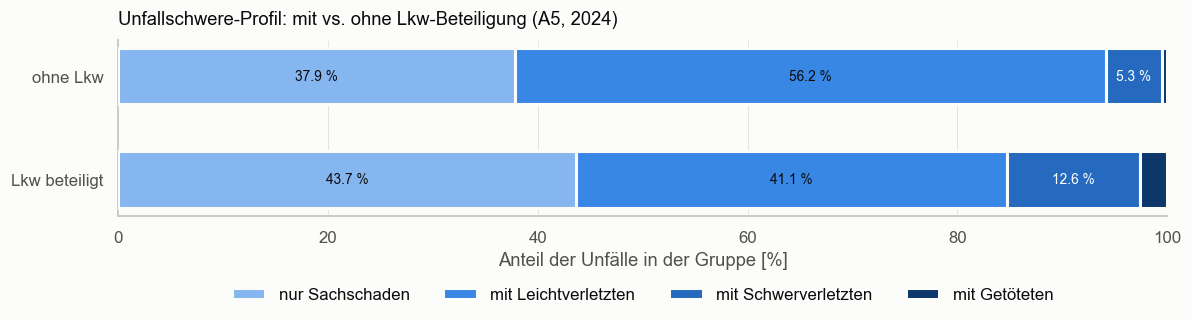

In [ ]:
# Unfallschwere-Profil nach Lkw-Beteiligung (Anteile innerhalb der Gruppe)
prof = (pd.crosstab(acc["LKW_beteiligt"].map(idx), acc["UKATEGORIE"], normalize="index") * 100)
prof = prof[[4, 3, 2, 1]]

fig, ax = plt.subplots(figsize=(11, 3.4))
left = np.zeros(len(prof))
for j, kat in enumerate([4, 3, 2, 1]):
    vals = prof[kat].values
    ax.barh(prof.index, vals, left=left, height=0.55, color=RAMP_ORD[j],
            label=KAT[kat], zorder=3, edgecolor=SURFACE, linewidth=2)  # 2px Trenner
    for y, (v, l) in enumerate(zip(vals, left)):
        if v > 3:
            ax.text(l + v/2, y, f"{v:.1f} %", ha="center", va="center", fontsize=9,
                    color="white" if j >= 2 else INK)
    left += vals

ax.set_xlabel("Anteil der Unfälle in der Gruppe [%]"); ax.set_xlim(0, 100)
ax.set_title("Unfallschwere-Profil: mit vs. ohne Lkw-Beteiligung (A5, 2024)", color=INK)
ax.grid(axis="y", visible=False)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.32))
plt.tight_layout()
plt.show()

### Interpretation

| Test | Vergleich | n | Chi² | p | Odds Ratio | Ergebnis (α = 0,05) |
|---|---|---|---|---|---|---|
| 2a | Lkw → **Personenschaden** (ja/nein) | 734 | 1,76 | 0,185 | 0,79 | **nicht signifikant** |
| 2b | Lkw → **schwerer/tödlicher** Ausgang | 734 | 15,06 | 0,00010 | **2,88** | **signifikant** |

> **Fallstrick bei der Odds Ratio:** `pd.crosstab` sortiert Zeilen und Spalten alphabetisch. Ohne
> explizites `reindex` landet „Lkw beteiligt" in der ersten Zeile – `fisher_exact` liefert dann **0,35**
> statt **2,88**, also exakt den Kehrwert. Die Kontingenztafel muss als
> `[[Referenz ohne Ereignis, Referenz mit Ereignis], [Exponiert ohne, Exponiert mit]]` orientiert sein.

Das Ergebnispaar ist aufschlussreich – und wäre bei nur einem der beiden Tests missverstanden worden:

* **Lkw verursachen nicht häufiger Unfälle mit Personenschaden** (Test 2a, p = 0,185). Der Anteil liegt mit
  56,3 % (mit Lkw) bzw. 62,1 % (ohne Lkw) sogar leicht darunter.
* **Wenn** ein Lkw beteiligt ist, ist der Ausgang aber **deutlich schwerer**: 15,3 % dieser Unfälle enden
  schwer oder tödlich gegenüber 5,9 % ohne Lkw – das **2,9-fache Risiko** (Test 2b, p = 0,0001). Bei den
  8 tödlichen Unfällen auf der A5 war in **5 Fällen** ein Lkw beteiligt.

Physikalisch ist das erwartbar: Die kinetische Energie skaliert linear mit der Masse, und ein 40-t-Lkw
bringt bei gleicher Geschwindigkeit rund das 25-Fache eines Pkw ein.

**Einschränkungen:** Beide Tests messen **Assoziation, nicht Kausalität**. Es fehlt die Normierung auf die
Fahrleistung (Lkw fahren mehr Kilometer auf der A5 als ihr Bestandsanteil vermuten lässt), und
„Lkw beteiligt" sagt nichts über die **Schuldfrage**. Für die 8 tödlichen Unfälle ist die Fallzahl zudem
sehr klein; die Odds Ratio aus Test 2b stützt sich aber auf 61 schwere/tödliche Unfälle insgesamt und ist
damit belastbar (kleinste erwartete Zellhäufigkeit ≥ 5, Chi²-Test gültig).